# Hotel Room-Nights Forecasting Pipeline

**Enjoy Costa Rica — Revenue Analytics**

Pronóstico de **room nights** (noches de habitación vendidas, `rooms_sold`) — la variable de demanda estructural del portafolio. Decisión de gerencia: demanda primero; monetario después (`revenue ≈ room nights × ADR`).

## Estructura del Notebook

| Sección | Descripción |
|---------|-------------|
| 0 | Setup & Configuración |
| 1 | Carga de Datos (validación de target + reporte de filas financieras NULL) |
| 2 | Análisis Exploratorio (EDA de room nights + chequeo de violaciones de capacidad) |
| 3 | Preprocesamiento & Feature Engineering (agregación NULL-safe, sin fuga de datos) |
| 4 | Modelos Estadísticos (Prophet, SARIMAX, ETS) — multi-paso alineado por fecha |
| 5 | Modelos de ML (LightGBM, XGBoost, CatBoost) — protocolo honesto recursivo |
| 6 | Deep Learning (PatchTST; TimesFM excluido honestamente en Windows) |
| 7 | Comparación Final (incluye baseline Seasonal Naive; DM con Newey-West) |
| 8 | Pronóstico Futuro (90 días, techo de capacidad, ocupación implícita) |
| 9 | Conclusiones & Advertencias Honestas |

> **Protocolo de evaluación**: todas las métricas del test son **multi-paso reales**
> (los modelos nunca ven los reales del test como entradas), en **room nights**,
> sobre la **misma serie** (portafolio agregado diario), con baseline de referencia.
>
> ⚠️ **DATOS SINTÉTICOS**: este notebook usa `hotel_roomnights_sample.csv`, un
> archivo ficticio generado con identidades físicas exactas. Las cifras validan
> la metodología; conecte el SQL real para números de negocio.

---
## Section 0: Setup & Imports

**Buenas prácticas aplicadas:**
- **Reproducibilidad**: semilla global (`SEED=42`) y configuración centralizada en `config.yaml`.
- **Separación de responsabilidades**: la lógica vive en `src/forecasting/` (43 tests); el notebook orquesta, visualiza y documenta.
- **Trazabilidad**: logging estructurado de cada componente.

In [1]:
import sys
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(name)s - %(levelname)s - %(message)s')

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Add src to path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

# Load config
CONFIG_PATH = PROJECT_ROOT / 'config.yaml'
with open(CONFIG_PATH) as f:
    CONFIG = yaml.safe_load(f)

RN = CONFIG['roomnights']
TARGET_COL = RN['target_col']            # rooms_sold
AVAIL_COL = RN['available_rooms_col']    # available_rooms

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version}")
print(f"NumPy: {np.__version__}, Pandas: {pd.__version__}")
print(f"Target: {TARGET_COL} (room nights) | Capacity col: {AVAIL_COL}")

Project root: C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec
Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
NumPy: 1.26.4, Pandas: 2.2.3
Target: rooms_sold (room nights) | Capacity col: available_rooms


In [2]:
# Import forecasting modules
from src.forecasting.data import (
    DataLoader, aggregate_daily_target, apply_capacity_ceiling, implied_occupancy,
)
from src.forecasting.eda import EDAAnalyzer, EDAVisualizer
from src.forecasting.preprocessing import PreprocessingPipeline
from src.forecasting.models.statistical import ProphetForecaster, SARIMAXForecaster, ETSForecaster
from src.forecasting.models.ml import LightGBMForecaster, XGBoostForecaster, CatBoostForecaster
from src.forecasting.models.dl import TimesFMForecaster, PatchTSTForecaster
from src.forecasting.evaluation import Evaluator, EvaluationVisualizer
from src.forecasting.forecasting.recursive import recursive_forecast

print("All modules imported successfully!")

All modules imported successfully!


---
## Section 1: Data Loading

**Módulo `data/` — `DataLoader` + validación de esquema por target**

| Práctica | Justificación |
|---|---|
| Validación de `rooms_sold` como target requerido | *Fail fast*: un dato sin la columna objetivo se detecta aquí |
| Reporte de filas financieras (NULL operacional) | Las filas de `enjoy_fac_hotel_financial` traen `rooms_sold` NULL; deben excluirse de la serie objetivo |
| Generador sintético determinista | Archivo ficticio con identidades físicas exactas para desarrollo offline |

In [3]:
# Load room-nights data (synthetic sample file for offline development).
# To use SQL: DataLoader(db_config={...}, csv_path=None).load(target_col=TARGET_COL)
sample_path = PROJECT_ROOT / RN['csv_path']
loader = DataLoader(csv_path=sample_path)

try:
    df = loader.load(target_col=TARGET_COL)
    print(f"Loaded {len(df)} rows from {sample_path.name}")
except FileNotFoundError:
    print("CSV not found. Generating synthetic room-nights sample...")
    df = loader.generate_roomnights_sample(
        n_hotels=5, n_days=365 * 3, seed=SEED, save_path=sample_path,
    )

print(f"\nShape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Hotels: {df['hotel_id'].nunique()}")
print(f"Financial rows (NULL {TARGET_COL}): {df[TARGET_COL].isna().sum()}")
df.head(10)

src.forecasting.data.loader - INFO - Loading data from CSV: C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\data\hotel_roomnights_sample.csv


src.forecasting.data.loader - INFO - Loaded 6260 rows from CSV.


src.forecasting.data.schema - INFO - Schema validation: 13 columns checked, 0 warnings, 0 errors


src.forecasting.data.loader - INFO - INFO: Column 'account_code' dtype is float64, expected ~object.


Loaded 6260 rows from hotel_roomnights_sample.csv

Shape: (6260, 13)
Date range: 2023-10-04 to 2026-10-02
Hotels: 5
Financial rows (NULL rooms_sold): 785


,date,hotel_id,revenue,room_revenue,rooms_sold,available_rooms,occupancy_rate,adr,revpar,cost_center,account_code,debit_amount,credit_amount
0,2023-10-04,HOTEL_001,8424.021329,6197.731621,31.0,80.0,0.3875,199.926826,77.471645,NaN,NaN,NaN,NaN
1,2023-10-04,HOTEL_001,3181.757256,2047.585498,NaN,NaN,NaN,NaN,NaN,CC-001,4001.0,3321.285532,0.0
2,2023-10-05,HOTEL_001,9442.161063,6946.798673,35.0,80.0,0.4375,198.479962,86.834983,NaN,NaN,NaN,NaN
3,2023-10-06,HOTEL_001,9301.434874,6843.263423,33.0,80.0,0.4125,207.371619,85.540793,NaN,NaN,NaN,NaN
4,2023-10-07,HOTEL_001,12580.132462,9255.470956,44.0,80.0,0.5500,210.351613,115.693387,NaN,NaN,NaN,NaN
5,2023-10-08,HOTEL_001,13122.995787,9654.867048,45.0,80.0,0.5625,214.552601,120.685838,NaN,NaN,NaN,NaN
6,2023-10-09,HOTEL_001,9072.918704,6675.139217,33.0,80.0,0.4125,202.276946,83.439240,NaN,NaN,NaN,NaN
7,2023-10-10,HOTEL_001,9299.686602,6841.977182,33.0,80.0,0.4125,207.332642,85.524715,NaN,NaN,NaN,NaN
8,2023-10-11,HOTEL_001,9628.199528,7083.671127,36.0,80.0,0.4500,196.768642,88.545889,NaN,NaN,NaN,NaN
9,2023-10-11,HOTEL_001,4328.923007,2381.533573,NaN,NaN,NaN,NaN,NaN,CC-001,4001.0,2902.575347,0.0


In [4]:
# Data schema overview
print("=== Data Types ===")
print(df.dtypes)
print(f"\n=== Missing Values ===")
print(df.isnull().sum())
print(f"\n=== Operational rows only ===")
ops = df[df[TARGET_COL].notna()]
print(f"{len(ops)} rows | mean {TARGET_COL}: {ops[TARGET_COL].mean():.1f} | "
      f"mean occupancy: {ops['occupancy_rate'].mean():.2f}")
print(f"\n=== Capacity violation check (rooms_sold > available_rooms) ===")
violations = (ops[TARGET_COL] > ops[AVAIL_COL]).sum()
print(f"Violations: {violations} (data-quality errors if > 0)")

=== Data Types ===
date               datetime64[ns]
hotel_id                   object
revenue                   float64
room_revenue              float64
rooms_sold                float64
available_rooms           float64
occupancy_rate            float64
adr                       float64
revpar                    float64
cost_center                object
account_code              float64
debit_amount              float64
credit_amount             float64
dtype: object

=== Missing Values ===
date                  0
hotel_id              0
revenue               0
room_revenue          0
rooms_sold          785
available_rooms     785
occupancy_rate      785
adr                 785
revpar              785
cost_center        5475
account_code       5475
debit_amount       5475
credit_amount      5475
dtype: int64

=== Operational rows only ===
5475 rows | mean rooms_sold: 69.1 | mean occupancy: 0.63

=== Capacity violation check (rooms_sold > available_rooms) ===
Violations: 0 (data-qua

---
## Section 2: Exploratory Data Analysis (EDA)

**Módulo `eda/` — EDA orientado a decisiones** (cada análisis responde una pregunta de modelado):

| Análisis | Pregunta | Decisión que alimenta |
|---|---|---|
| Descriptiva de room nights | ¿Escala y dispersión de la demanda? | Umbral de error aceptable (habitaciones) |
| Descomposición STL | ¿Tendencia + estacionalidad? | Modelos de componentes (Prophet/ETS) |
| ADF/KPSS | ¿Estacionariedad? | Diferenciación para SARIMA |
| ACF/PACF | ¿Qué rezagos predicen? | Lags candidatos para ML |
| Outliers | ¿Días anómalos? | Flag/cap en preprocessing |
| Correlaciones | ¿Relación con ADR/occupancy? | Solo comprensión — NO serán features (futuro desconocido) |

In [5]:
# Initialize EDA
eda = EDAAnalyzer(df, date_col='date', target_cols=[TARGET_COL])
eda_viz = EDAVisualizer(eda)

desc_stats = eda.descriptive_statistics()
desc_stats

src.forecasting.eda.analyzer - INFO - Descriptive statistics computed for 1 columns.


,count,mean,median,std,min,q25,q50,q75,max,skewness,kurtosis,cv
column,,,,,,,,,,,,
rooms_sold,5475,69.091142,59.0,31.365273,19.0,47.0,59.0,83.0,186.0,1.154116,0.51784,0.45397


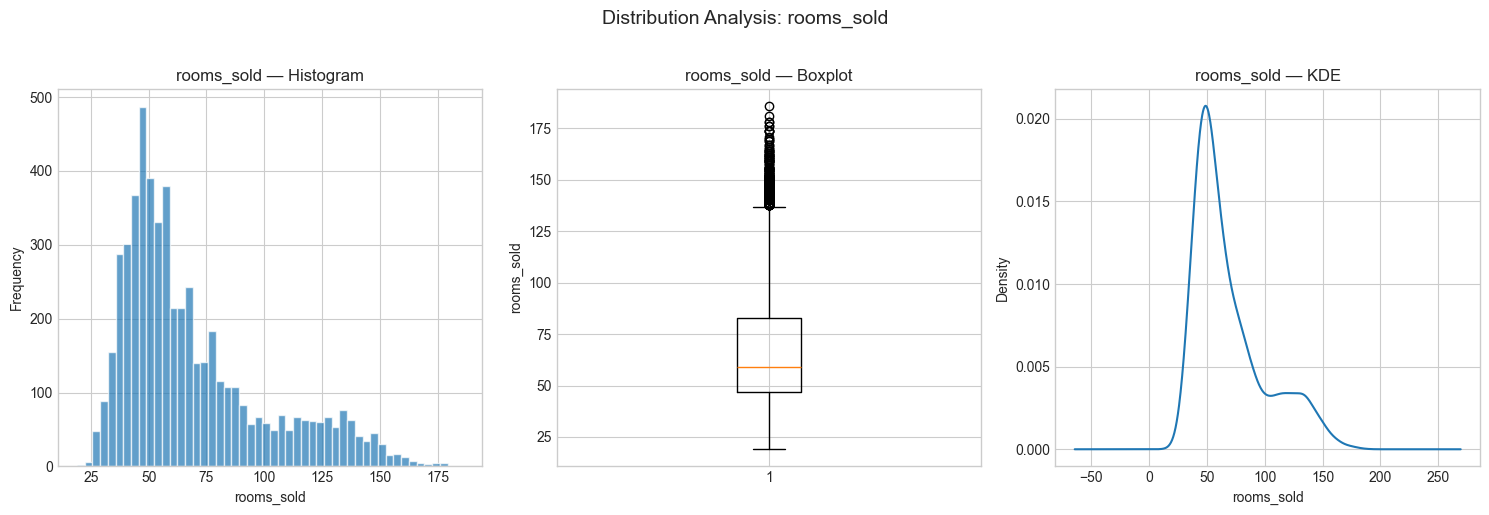

In [6]:
# Distribution plot
fig = eda_viz.plot_distributions(TARGET_COL)
plt.show()

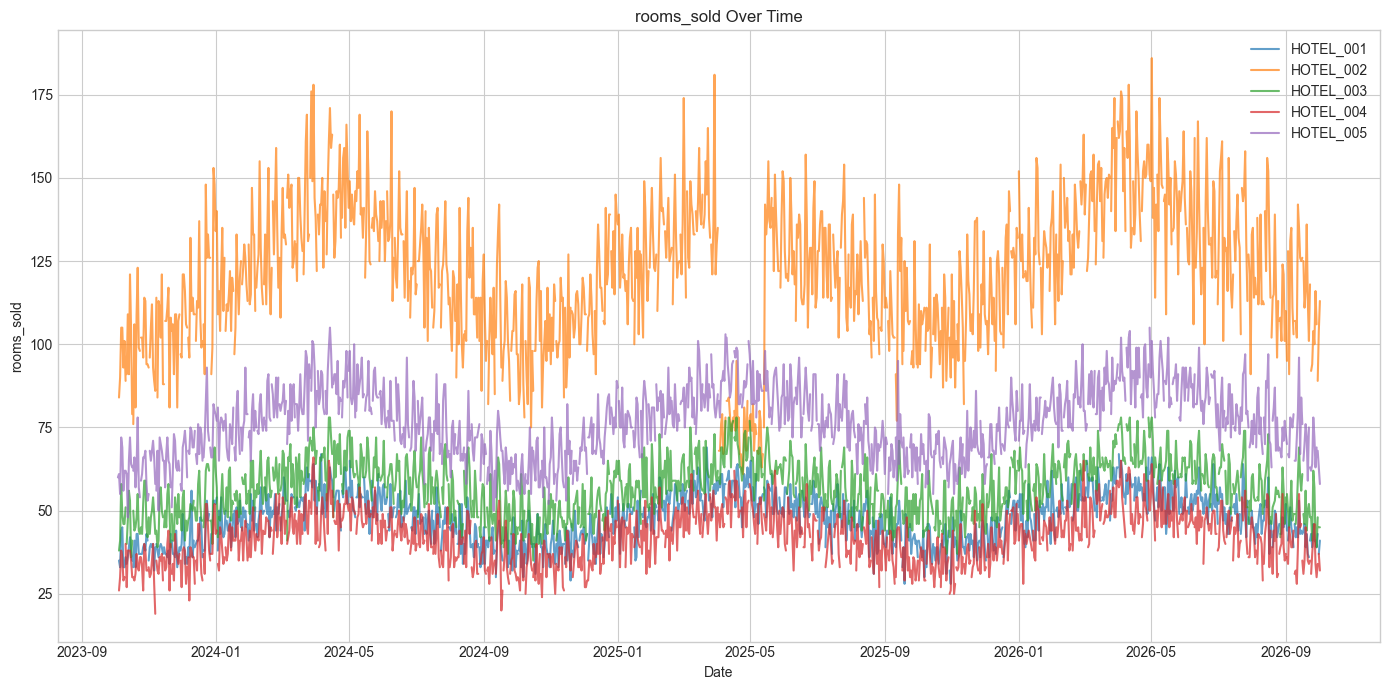

In [7]:
# Time series plot (per hotel)
fig = eda_viz.plot_time_series(TARGET_COL)
plt.show()

src.forecasting.eda.analyzer - INFO - Decomposition complete: model=additive, period=7


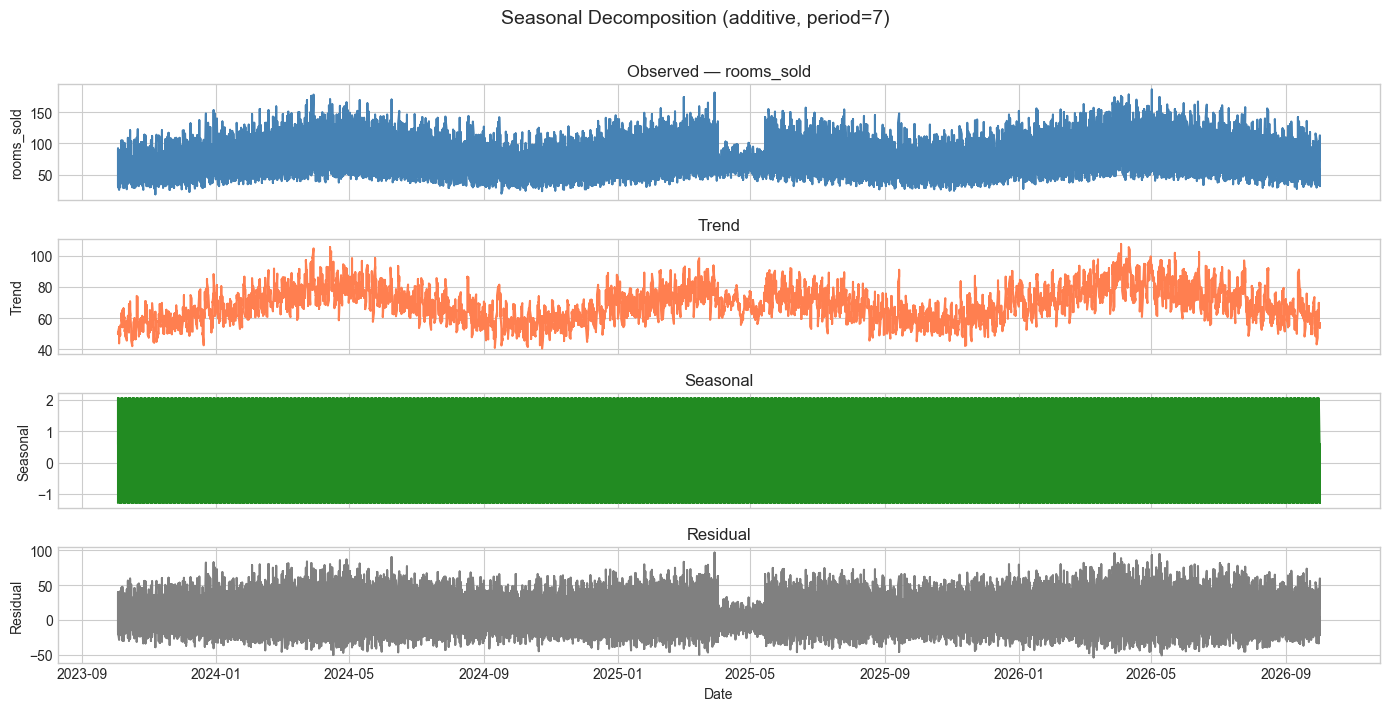

In [8]:
# Time series decomposition
decomp = eda.time_series_decomposition(TARGET_COL, period=7, model='additive')
fig = eda_viz.plot_decomposition(decomp, TARGET_COL)
plt.show()

In [9]:
# Stationarity tests
results = eda.stationarity_tests(TARGET_COL)
for r in results:
    print(f"  {r.test_name}: stat={r.statistic:.4f}, p={r.p_value:.4f} — {r.interpretation}")

C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\src\forecasting\eda\analyzer.py:263: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, p_val, n_lags, crit_vals = kpss(series, regression="c", nlags="auto")
src.forecasting.eda.analyzer - INFO - Augmented Dickey-Fuller: stat=-4.7073, p=0.0001 — Series IS stationary (reject unit root null)


src.forecasting.eda.analyzer - INFO - KPSS: stat=1.5965, p=0.0100 — Series is NOT stationary (reject stationarity null)


  Augmented Dickey-Fuller: stat=-4.7073, p=0.0001 — Series IS stationary (reject unit root null)
  KPSS: stat=1.5965, p=0.0100 — Series is NOT stationary (reject stationarity null)


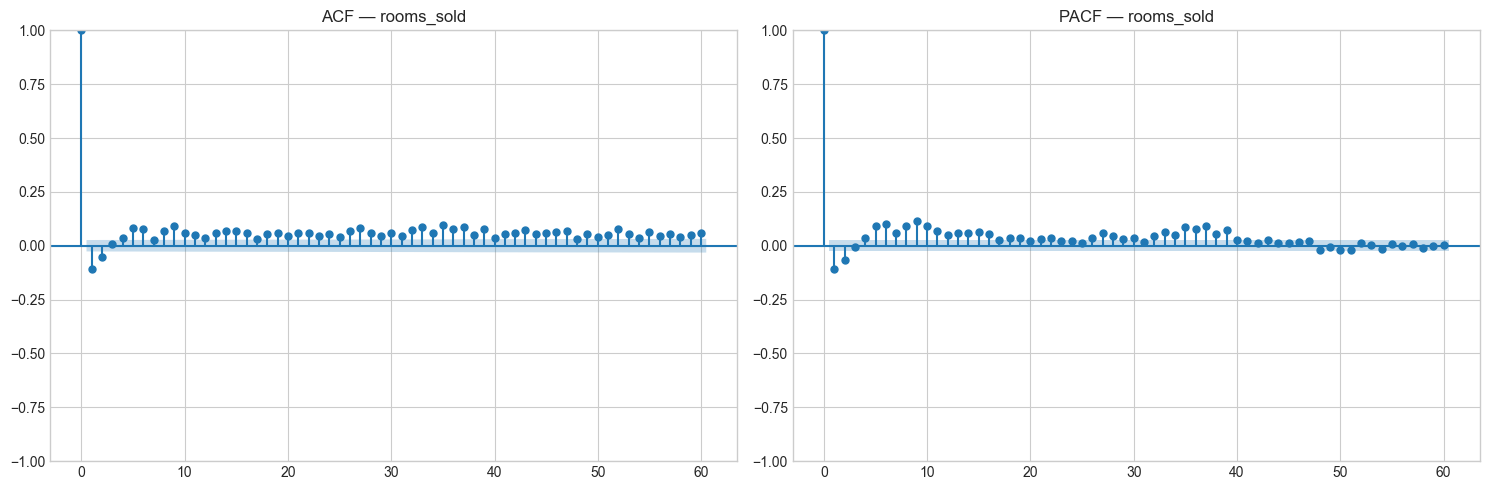

In [10]:
# ACF/PACF
fig = eda_viz.plot_acf_pacf(TARGET_COL, nlags=60)
plt.show()

In [11]:
# Seasonality detection
seasonality = eda.seasonality_detection(TARGET_COL)
for s in seasonality:
    print(f"  {s.pattern}: strength={s.strength:.3f}, p={s.p_value:.4f}")

src.forecasting.eda.analyzer - INFO - Seasonality — weekly: strength=0.002, p=0.0000


src.forecasting.eda.analyzer - INFO - Seasonality — monthly: strength=0.005, p=0.0000


src.forecasting.eda.analyzer - INFO - Seasonality — yearly: strength=0.006, p=0.0000


  weekly: strength=0.002, p=0.0000
  monthly: strength=0.005, p=0.0000
  yearly: strength=0.006, p=0.0000


src.forecasting.eda.analyzer - INFO - Outlier detection (iqr): 257 outliers (4.69%)


Outliers: 257 (4.69%)


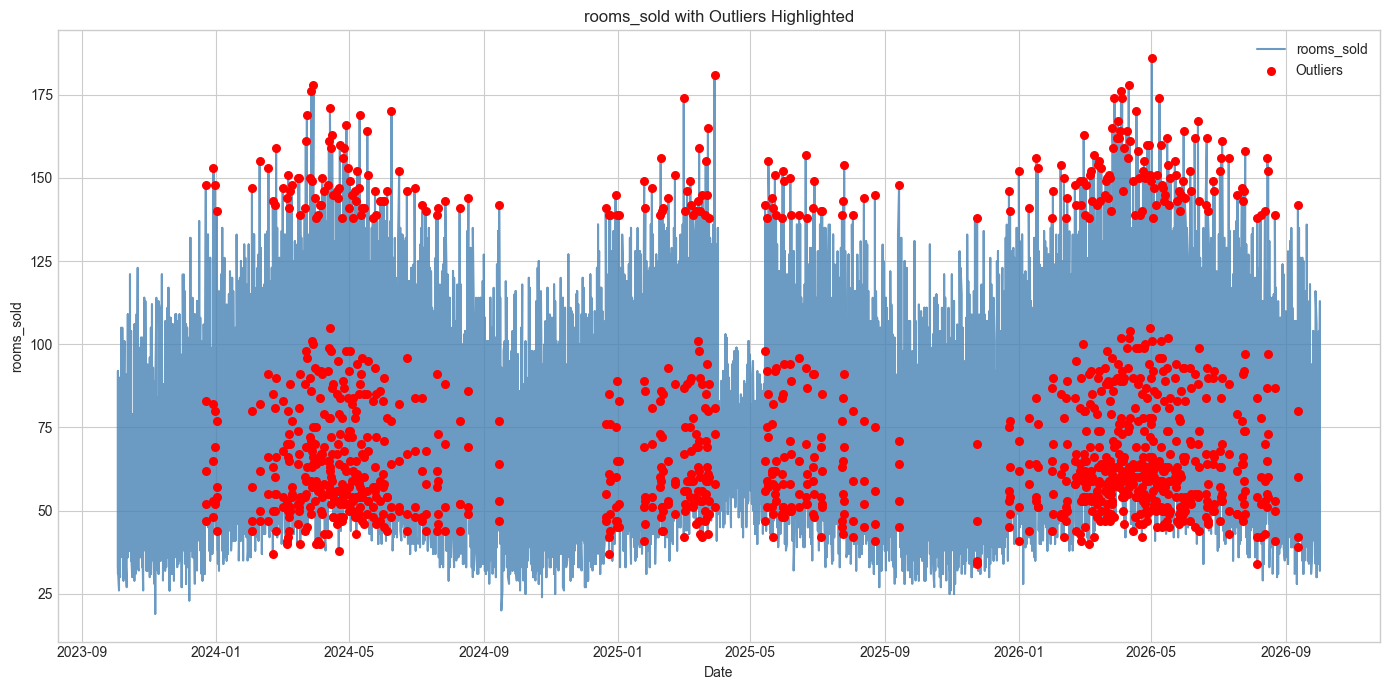

In [12]:
# Outlier detection
outlier_result = eda.outlier_detection(TARGET_COL, method='iqr', threshold=1.5)
print(f"Outliers: {outlier_result.n_outliers} ({outlier_result.outlier_pct}%)")
fig = eda_viz.plot_outliers(TARGET_COL, outlier_indices=outlier_result.outlier_indices)
plt.show()

src.forecasting.eda.analyzer - INFO - Correlation matrix computed (pearson) for 6 columns.


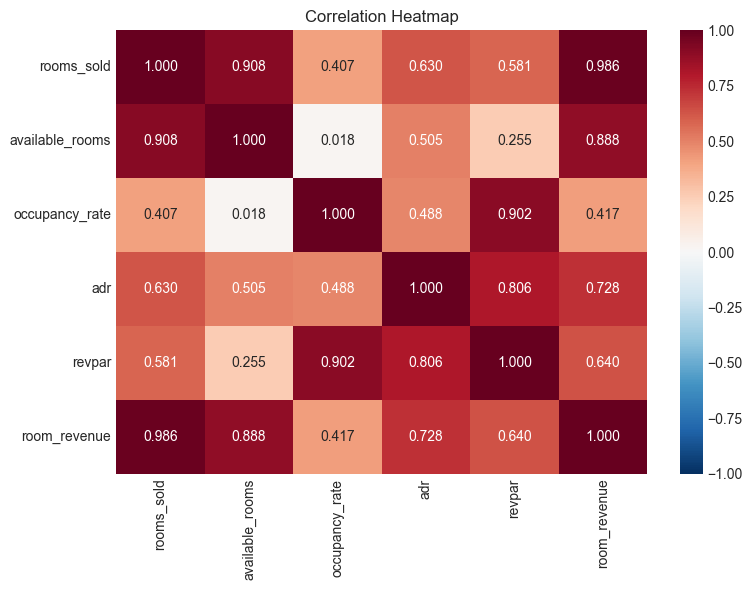

In [13]:
# Correlation analysis (understanding only — these are NOT ML features:
# their future values are unknown; see the forward-known rule in Section 5)
corr = eda.correlation_analysis(
    columns=[TARGET_COL, AVAIL_COL, 'occupancy_rate', 'adr', 'revpar', 'room_revenue']
)
fig = eda_viz.plot_correlation_heatmap(corr)
plt.show()

---
## Section 3: Preprocessing & Feature Engineering

**Módulo `preprocessing/` — diseño anti-fuga (leakage-safe)**

**Protocolo de números honestos:**
- **Agregación NULL-safe**: la serie diaria suma solo filas operacionales; los NULL de la tabla financiera se excluyen ANTES de imputar (nunca contaminan el target).
- El target **NO se escala** → métricas en room nights reales.
- Lags/rollings de `rooms_sold` calculados con `shift` (cada feature en `t` usa solo `t-1` o antes).
- Features monetarias (`revenue`, `room_revenue`) **excluidas de ML**: su futuro es desconocido (regla forward-known).
- `available_rooms` SÍ es feature: la capacidad es planeada por el hotel (forward-known).
- Split temporal 70/15/15 con gap de 7 días; evaluación del test **recursiva multi-paso**.

In [14]:
# ------------------------------------------------------------------
# HONEST EVALUATION PROTOCOL (same as the revenue pipeline)
#   1. All models on the SAME series: daily portfolio room nights.
#   2. Every test prediction is MULTI-STEP (only pre-test information).
#   3. ML models evaluated RECURSIVELY: predictions feed back as lags.
#   4. SeasonalNaive baseline included: models must beat it to be useful.
# ------------------------------------------------------------------

# NULL-safe daily aggregation (financial rows excluded BEFORE imputation)
df_agg, agg_report = aggregate_daily_target(
    df, target_col=TARGET_COL, date_col='date', sum_cols=[AVAIL_COL],
)
print(f"Aggregate series: {len(df_agg)} days | {df_agg['date'].min().date()} -> {df_agg['date'].max().date()}")
print(f"NULL-target rows excluded: {agg_report['n_excluded_null_rows']} | "
      f"gap dates: {agg_report['n_gap_dates']}")

pipeline = PreprocessingPipeline(
    missing_strategy=CONFIG['preprocessing']['missing_values']['strategy'],
    outlier_method=CONFIG['preprocessing']['outliers']['method'],
    outlier_action=CONFIG['preprocessing']['outliers']['action'],
    feature_config=RN['features'],          # target_cols: [rooms_sold]
    split_config=CONFIG['preprocessing']['split'],
    scale_method=None,                      # NO scaling: metrics in real room nights
    target_cols=[TARGET_COL],
)

split_result, train_feat, val_feat, test_feat = pipeline.run(df_agg, date_col='date')

print(f"Train: {len(train_feat)}d | Val: {len(val_feat)}d | Test: {len(test_feat)}d | "
      f"gap={split_result.gap_days}d")
print(f"train_end={split_result.train_end.date()}  val_end={split_result.val_end.date()}")

keep = ['date', TARGET_COL, AVAIL_COL]
train_df = train_feat[keep].copy()
val_df = val_feat[keep].copy()
test_df = test_feat[keep].copy()

test_start = test_df['date'].min()
actuals_test = test_df[TARGET_COL].values
test_dates = pd.to_datetime(test_df['date'])

# ALL observations strictly before the test window (contiguous calendar series)
history_eval = df_agg.loc[df_agg['date'] < test_start, ['date', TARGET_COL, AVAIL_COL]].reset_index(drop=True)
full_history = df_agg[keep].copy()

print(f"History available at test time: {len(history_eval)} days "
      f"(ends {history_eval['date'].max().date()})")

src.forecasting.data.aggregation - INFO - Daily aggregation of 'rooms_sold': 1095 days | 785 NULL-target rows excluded | 0 gap dates reindexed to NaN


src.forecasting.preprocessing.splitter - INFO - Temporal split: train=766, val=157, test=158 (gap=7 days)


src.forecasting.preprocessing.splitter - INFO - Split dates: train_end=2025-11-07, val_end=2026-04-20


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 44 columns


Aggregate series: 1095 days | 2023-10-04 -> 2026-10-02
NULL-target rows excluded: 785 | gap dates: 0


...

src.forecasting.preprocessing.outliers - INFO - Outliers in 'available_rooms': 42 (5.48%) — action: flag


src.forecasting.preprocessing.outliers - INFO - Outliers in 'rooms_sold': 1 (0.64%) — action: flag


src.forecasting.preprocessing.outliers - INFO - Outliers in 'rooms_sold': 1 (0.63%) — action: flag


src.forecasting.preprocessing.pipeline - INFO - Pipeline complete: train=766 rows/50 cols, val=157, test=158


Train: 766d | Val: 157d | Test: 158d | gap=7d
train_end=2025-11-07  val_end=2026-04-20
History available at test time: 937 days (ends 2026-04-27)


In [15]:
# Show engineered features for the room-nights target
feature_cols_all = [
    c for c in train_feat.columns
    if c not in ('date', 'hotel_id', TARGET_COL, 'revenue', 'room_revenue')
]
print(f"Engineered features ({len(feature_cols_all)}):")
for i, col in enumerate(feature_cols_all, 1):
    print(f"  {i:2d}. {col}")

Engineered features (48):
   1. available_rooms
   2. year
   3. quarter
   4. month
   5. week
   6. day
   7. dayofweek
   8. dayofyear
   9. is_weekend
  10. is_month_start
  11. is_month_end
  12. is_quarter_start
  13. is_quarter_end
  14. dayofweek_sin
  15. dayofweek_cos
  16. dayofyear_sin
  17. dayofyear_cos
  18. month_sin
  19. month_cos
  20. rooms_sold_lag_1
  21. rooms_sold_lag_7
  22. rooms_sold_lag_14
  23. rooms_sold_lag_30
  24. rooms_sold_lag_365
  25. rooms_sold_rmean_7
  26. rooms_sold_rstd_7
  27. rooms_sold_rmin_7
  28. rooms_sold_rmax_7
  29. rooms_sold_rmean_14
  30. rooms_sold_rstd_14
  31. rooms_sold_rmin_14
  32. rooms_sold_rmax_14
  33. rooms_sold_rmean_30
  34. rooms_sold_rstd_30
  35. rooms_sold_rmin_30
  36. rooms_sold_rmax_30
  37. rooms_sold_rmean_90
  38. rooms_sold_rstd_90
  39. rooms_sold_rmin_90
  40. rooms_sold_rmax_90
  41. rooms_sold_emean
  42. rooms_sold_estd
  43. is_holiday
  44. is_pre_holiday
  45. is_post_holiday
  46. days_to_holiday
  4

---
## Section 4: Statistical Models

**Módulo `models/statistical/` — modelos de estructura explícita**

**Buenas prácticas comunes**: entrenados con **toda la historia previa al test** (serie continua) y evaluados con predicciones **multi-paso alineadas por fecha** — el mismo escenario de producción.

| Modelo | Qué es | Por qué funciona (o no) aquí |
|---|---|---|
| **Prophet** | Tendencia flexible + estacionalidad semanal/anual (Fourier) + festivos CR | Ideal para horizontes largos: proyecta componentes globales de un tirón |
| **SARIMAX** | ARIMA estacional con auto_arima por AIC | Fuerte a corto plazo; en 158 días puede derivar si no elige componente estacional |
| **ETS (Holt-Winters)** | Suavizado exponencial con selección por AIC | Robusto y parsimonioso |
| **SeasonalNaive** | Repite la última semana | **Disciplina de baseline** |

In [16]:
# Statistical models see all observed days strictly before the test window
train_val_df = history_eval[['date', TARGET_COL]].copy()
print(f"Statistical training window: {len(train_val_df)} days, "
      f"ends {train_val_df['date'].max().date()}")

Statistical training window: 937 days, ends 2026-04-27


---
### Hyperparameter Tuning (honest objective)

**Regla del review especialista**: se tunea contra la métrica que el negocio va
a sentir — el **MAE del pronóstico recursivo multi-paso sobre la ventana de
validación** — nunca un atajo one-step que optimiza un problema distinto.

- **Prophet**: grid search (changepoint/seasonality prior scale), pronóstico nativo por fecha (aquí).
- **GBMs** (Sección 5, tras definir las features): Optuna TPE, 25 trials por familia; cada trial = fit con early stopping en val → refit en historia pre-val → pronóstico recursivo del val → MAE.

Los hiperparámetros quedan congelados; el backtesting (Sección 7.5) los
reutiliza sin re-tunear — se mide estabilidad de ranking, no se re-selecciona.

In [17]:
# --- Prophet tuning (multi-step MAE on the validation window) ---
from src.forecasting.models.tuning import tune_prophet_grid, tune_gbm

val_start = val_df['date'].min()
pre_val_history = df_agg.loc[df_agg['date'] < val_start, ['date', TARGET_COL, AVAIL_COL]].reset_index(drop=True)
val_dates_t = pd.to_datetime(val_df['date'])
val_actuals_t = val_df[TARGET_COL].values

prophet_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.05, 0.1],
    'seasonality_prior_scale': [1.0, 10.0, 30.0],
}
prophet_best, prophet_best_mae = tune_prophet_grid(
    pre_val_history[['date', TARGET_COL]], val_dates_t, val_actuals_t,
    prophet_grid, target_col=TARGET_COL,
)
print(f"Prophet tuned: {prophet_best} | recursive val MAE: {prophet_best_mae:.2f}")

cmdstanpy - DEBUG - cmd: where.exe tbb.dll
cwd: None


cmdstanpy - DEBUG - Adding TBB (C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\prophet\stan_model\cmdstan-2.33.1\stan\lib\stan_math\lib\tbb) to PATH


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmpt5ogn7tv\h2o6lt6g.json


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmpt5ogn7tv\q3_gj3pl.json


cmdstanpy - DEBUG - idx 0


...

09:42:32 - cmdstanpy - INFO - Chain [1] done processing


cmdstanpy - INFO - Chain [1] done processing


src.forecasting.models.statistical.prophet_model - INFO - Prophet fitted in 0.20 seconds on 773 rows.


src.forecasting.models.tuning - INFO - Tuning Prophet: best val MAE=16.6657 with {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 1.0}


Prophet tuned: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 1.0} | recursive val MAE: 16.67


In [18]:
# --- Prophet ---
print("Training Prophet on the full pre-test history...")
prophet = ProphetForecaster(
    changepoint_prior_scale=prophet_best['changepoint_prior_scale'],
    seasonality_prior_scale=prophet_best['seasonality_prior_scale'],
)
prophet.fit(train_val_df, target_col=TARGET_COL, date_col='date')
prophet_result = prophet.predict(test_df, target_col=TARGET_COL, date_col='date')
print(f"Prophet: {len(prophet_result.predictions)} multi-step predictions")

cmdstanpy - DEBUG - cmd: where.exe tbb.dll
cwd: None


cmdstanpy - DEBUG - TBB already found in load path


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmpt5ogn7tv\j_0i5so6.json


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmpt5ogn7tv\nghmh1cd.json


cmdstanpy - DEBUG - idx 0


...

Training Prophet on the full pre-test history...


09:42:32 - cmdstanpy - INFO - Chain [1] done processing


cmdstanpy - INFO - Chain [1] done processing


src.forecasting.models.statistical.prophet_model - INFO - Prophet fitted in 0.23 seconds on 937 rows.


Prophet: 158 multi-step predictions


In [19]:
# --- SARIMAX ---
print("Training SARIMAX (auto_arima, weekly seasonality)...")
sarimax = SARIMAXForecaster(
    seasonal_periods=CONFIG['models']['statistical']['sarimax']['seasonal_periods'],
    stepwise=CONFIG['models']['statistical']['sarimax']['stepwise'],
)
sarimax.fit(train_val_df, target_col=TARGET_COL, date_col='date')
print(f"  order={sarimax._order}, seasonal_order={sarimax._seasonal_order}")
sarimax_result = sarimax.predict(test_df, target_col=TARGET_COL, date_col='date')
print(f"SARIMAX: {len(sarimax_result.predictions)} date-aligned multi-step predictions")

Training SARIMAX (auto_arima, weekly seasonality)...


src.forecasting.models.statistical.sarimax_model - INFO - SARIMAX fitted in 55.14 sec: order=(2, 1, 1), seasonal_order=(2, 0, 0, 7)


  order=(2, 1, 1), seasonal_order=(2, 0, 0, 7)
SARIMAX: 158 date-aligned multi-step predictions


In [20]:
# --- ETS (Holt-Winters) ---
print("Training ETS (auto selection by AIC)...")
ets = ETSForecaster(seasonal_periods=7, damped_trend=True, auto_select=True)
ets.fit(train_val_df, target_col=TARGET_COL, date_col='date')
print(f"  selected: {ets._model_params}")
ets_result = ets.predict(test_df, target_col=TARGET_COL, date_col='date')
print(f"ETS: {len(ets_result.predictions)} date-aligned multi-step predictions")

C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\ba

Training ETS (auto selection by AIC)...


C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


src.forecasting.models.statistical.ets_model - INFO - ETS fitted in 1.25 sec: params={'trend': None, 'seasonal': 'add', 'damped_trend': False, 'aic': 5559.944319688527}, AIC=5559.94


  selected: {'trend': None, 'seasonal': 'add', 'damped_trend': False, 'aic': 5559.944319688527}
ETS: 158 date-aligned multi-step predictions


SeasonalNaive: 158 predictions (last observed week cycled)


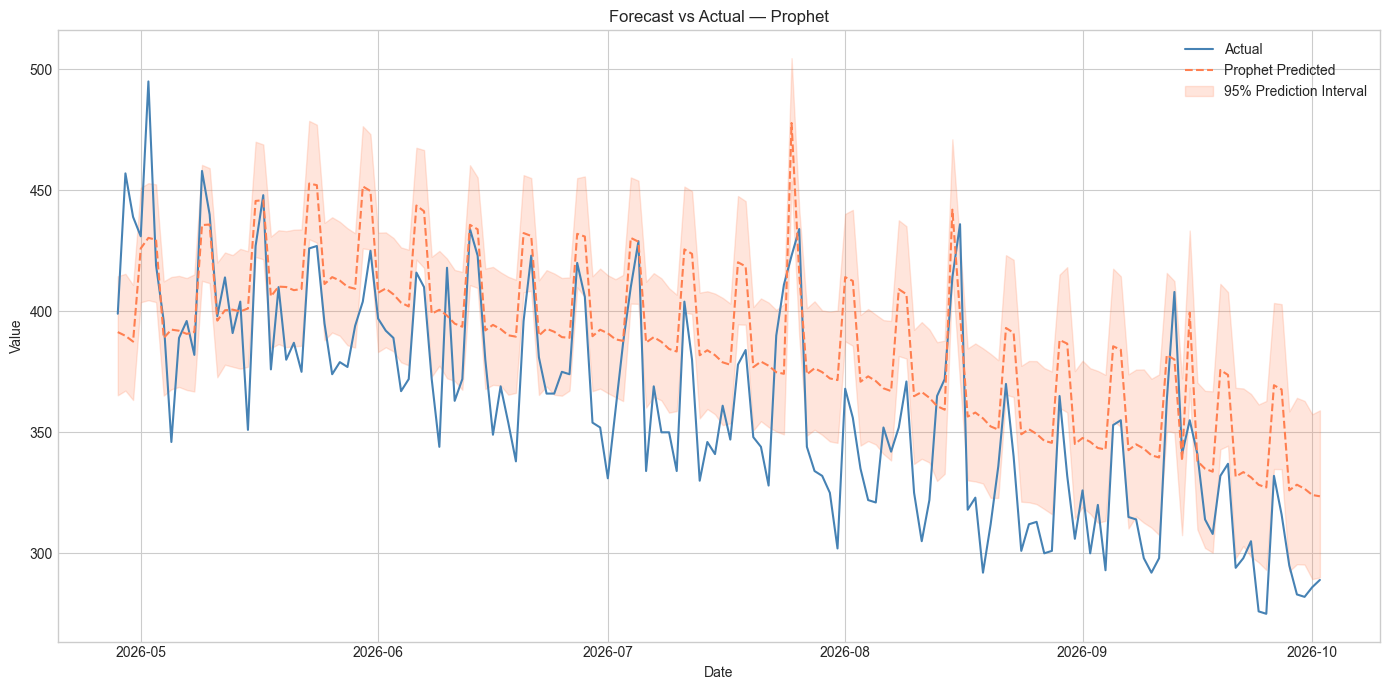

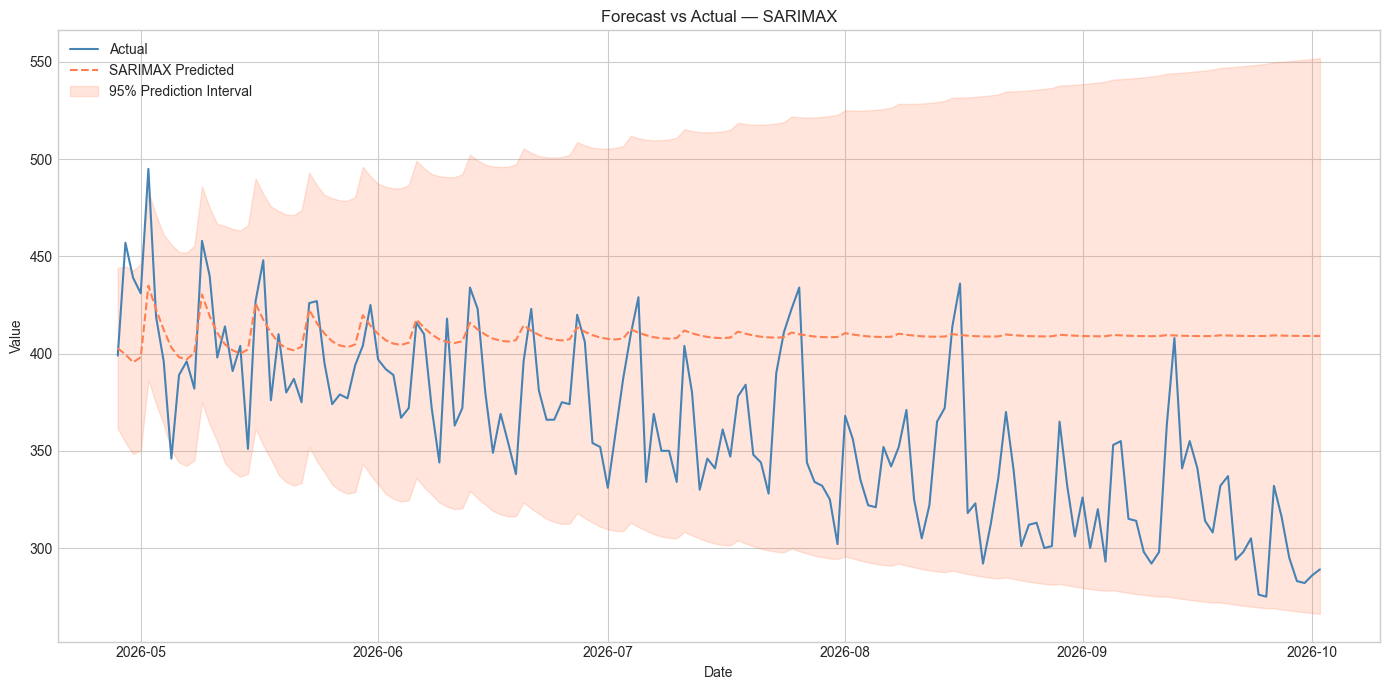

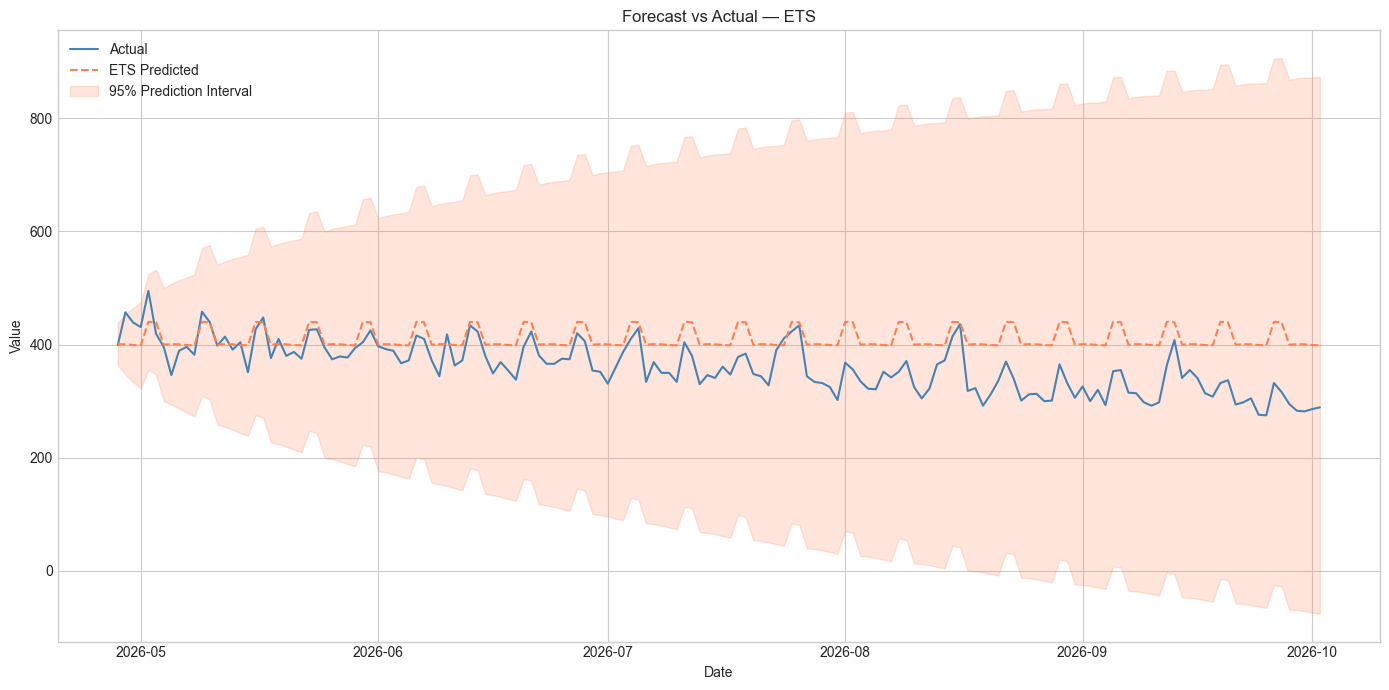

In [21]:
# --- Seasonal Naive baseline ---
last_week = history_eval[TARGET_COL].values[-7:]
naive_preds = np.array([last_week[i % 7] for i in range(len(test_df))])
print(f"SeasonalNaive: {len(naive_preds)} predictions (last observed week cycled)")

# Visualize statistical model forecasts
eval_viz = EvaluationVisualizer()
for name, result in [('Prophet', prophet_result), ('SARIMAX', sarimax_result), ('ETS', ets_result)]:
    fig = eval_viz.plot_forecast(
        result.actuals, result.predictions, dates=test_dates,
        model_name=name, lower_bound=result.lower_bound, upper_bound=result.upper_bound,
    )
    plt.show()

---
## Section 5: Machine Learning Models

**Módulo `models/ml/` — Gradient Boosting (LightGBM, XGBoost, CatBoost)**

**Protocolo honesto en 3 pasos por modelo:**
1. **Fit en train + early stopping en val** → iteraciones óptimas elegidas sin tocar el test.
2. **Refit en TODA la historia pre-test** con el nº de iteraciones ya fijado.
3. **Predicción recursiva del test**: cada predicción se realimenta como lag — los reales del test jamás son entradas.

**Regla forward-known aplicada:**
- Features = lags/rollings/expanding de `rooms_sold` + calendario + festivos CR + `available_rooms` (capacidad planeada → conocida a futuro, se arrastra con el último valor observado).
- **Excluidas**: toda feature derivada de `revenue`/`room_revenue` (ADR/RevPAR/occupancy realizados) — su valor futuro no existe; usarlas obligaría a inventar entradas fantasma.

In [22]:
# ML features: rooms_sold family + calendar + holidays + available_rooms.
# Monetary families excluded (future unknown) per the forward-known rule.
excluded_prefixes = tuple(RN['excluded_feature_prefixes'])
drop_cols = ['date', 'hotel_id', TARGET_COL] + list(excluded_prefixes)
feature_cols_ml = [
    c for c in train_feat.columns
    if c not in drop_cols
    and not c.startswith(excluded_prefixes)
    and not c.startswith('occupancy_rate')
    and not c.startswith('adr')
    and not c.startswith('revpar')
]
assert AVAIL_COL in feature_cols_ml, "available_rooms (forward-known) must be an ML feature"
print(f"ML features ({len(feature_cols_ml)}):")
print(feature_cols_ml)

ML features (48):
['available_rooms', 'year', 'quarter', 'month', 'week', 'day', 'dayofweek', 'dayofyear', 'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'dayofweek_sin', 'dayofweek_cos', 'dayofyear_sin', 'dayofyear_cos', 'month_sin', 'month_cos', 'rooms_sold_lag_1', 'rooms_sold_lag_7', 'rooms_sold_lag_14', 'rooms_sold_lag_30', 'rooms_sold_lag_365', 'rooms_sold_rmean_7', 'rooms_sold_rstd_7', 'rooms_sold_rmin_7', 'rooms_sold_rmax_7', 'rooms_sold_rmean_14', 'rooms_sold_rstd_14', 'rooms_sold_rmin_14', 'rooms_sold_rmax_14', 'rooms_sold_rmean_30', 'rooms_sold_rstd_30', 'rooms_sold_rmin_30', 'rooms_sold_rmax_30', 'rooms_sold_rmean_90', 'rooms_sold_rstd_90', 'rooms_sold_rmin_90', 'rooms_sold_rmax_90', 'rooms_sold_emean', 'rooms_sold_estd', 'is_holiday', 'is_pre_holiday', 'is_post_holiday', 'days_to_holiday', 'rooms_sold_outlier', 'available_rooms_outlier']


In [23]:
# --- GBM tuning via Optuna: objective = recursive multi-step val MAE ---
FUTURE_KNOWN = [AVAIL_COL]  # forward-known: planned capacity (re-declared below)

def prepare_features(hist):
    out = pipeline.feature_engineer.transform(hist)
    out = pipeline.holiday_engineer.transform(out)
    return pipeline.outlier_handler.transform(out)

lgbm_base = {k: v for k, v in LightGBMForecaster().params.items()
             if k not in ('early_stopping_rounds', 'categorical_features')}
def suggest_lgbm(t):
    return {
        'num_leaves': t.suggest_int('num_leaves', 16, 128),
        'learning_rate': t.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'min_child_samples': t.suggest_int('min_child_samples', 5, 60),
        'feature_fraction': t.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': t.suggest_float('bagging_fraction', 0.6, 1.0),
        'lambda_l1': t.suggest_float('lambda_l1', 1e-3, 10.0, log=True),
    }
tuned_lgbm = tune_gbm(
    LightGBMForecaster, suggest_lgbm, lgbm_base,
    train_feat, val_feat, pre_val_history, val_dates_t, val_actuals_t,
    feature_cols_ml, pipeline.feature_engineer, pipeline.holiday_engineer,
    prepare_features, target_col=TARGET_COL,
    n_trials=25, seed=SEED, future_known_cols=FUTURE_KNOWN,
)

xgb_base = {k: v for k, v in XGBoostForecaster().params.items() if k != 'early_stopping_rounds'}
def suggest_xgb(t):
    return {
        'max_depth': t.suggest_int('max_depth', 3, 10),
        'learning_rate': t.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'subsample': t.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': t.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda': t.suggest_float('reg_lambda', 1e-2, 10.0, log=True),
        'min_child_weight': t.suggest_int('min_child_weight', 1, 20),
    }
tuned_xgb = tune_gbm(
    XGBoostForecaster, suggest_xgb, xgb_base,
    train_feat, val_feat, pre_val_history, val_dates_t, val_actuals_t,
    feature_cols_ml, pipeline.feature_engineer, pipeline.holiday_engineer,
    prepare_features, target_col=TARGET_COL,
    n_trials=25, seed=SEED, future_known_cols=FUTURE_KNOWN,
)

cat_base = {k: v for k, v in CatBoostForecaster().params.items()
            if k not in ('early_stopping_rounds', 'cat_features')}
def suggest_cat(t):
    return {
        'depth': t.suggest_int('depth', 4, 10),
        'learning_rate': t.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg': t.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
        'bagging_temperature': t.suggest_float('bagging_temperature', 0.0, 1.0),
    }
tuned_cat = tune_gbm(
    CatBoostForecaster, suggest_cat, cat_base,
    train_feat, val_feat, pre_val_history, val_dates_t, val_actuals_t,
    feature_cols_ml, pipeline.feature_engineer, pipeline.holiday_engineer,
    prepare_features, target_col=TARGET_COL,
    n_trials=25, seed=SEED, future_known_cols=FUTURE_KNOWN,
)

print("LightGBM tuned:", tuned_lgbm)
print("XGBoost tuned:", tuned_xgb)
print("CatBoost tuned:", tuned_cat)

src.forecasting.models.ml.lgbm_model - INFO - LightGBM fitted in 0.08 sec, best iteration: 68


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 44 columns


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.preprocessing.outliers - INFO - Outliers in 'rooms_sold': 2 (0.26%) — action: flag


src.forecasting.preprocessing.outliers - INFO - Outliers in 'available_rooms': 42 (5.43%) — action: flag


...

src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 100/157 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 150/157 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast complete: 157 steps (incremental path)


src.forecasting.models.tuning - INFO - Tuning CatBoostForecaster: best recursive val MAE=17.1574 over 25 trials


LightGBM tuned: {'objective': 'regression', 'metric': 'mae', 'boosting_type': 'gbdt', 'num_leaves': 98, 'learning_rate': 0.08630046149491287, 'n_estimators': 1000, 'max_depth': -1, 'min_child_samples': 29, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 0.1, 'verbose': -1, 'n_jobs': -1, 'random_state': 42, 'feature_fraction': 0.7521318160746847, 'bagging_fraction': 0.769317426307569, 'lambda_l1': 0.0024699107400156625}
XGBoost tuned: {'objective': 'reg:squarederror', 'eval_metric': 'mae', 'max_depth': 4, 'learning_rate': 0.012547353147528846, 'n_estimators': 1000, 'subsample': 0.6110193566422457, 'colsample_bytree': 0.7104445710663886, 'reg_alpha': 0.1, 'reg_lambda': 0.4870107762232101, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0, 'min_child_weight': 12}
CatBoost tuned: {'loss_function': 'MAE', 'depth': 5, 'learning_rate': 0.03823637497236525, 'iterations': 1000, 'l2_leaf_reg': 3.331838398390531, 'bagging_temperature': 0.5769491738896779, 'random_seed': 

In [24]:
FUTURE_KNOWN = [AVAIL_COL]  # capacity is planned: carried through recursion

def fit_gbm_honest(model_obj, name):
    """3-step honest GBM protocol: ES on val -> refit pre-test history -> recursive test forecast."""
    print(f"Training {name} (early stopping on val)...")
    model_obj.fit(train_feat, target_col=TARGET_COL, date_col='date',
                  feature_cols=feature_cols_ml, val_df=val_feat)
    print(f"  best_iteration={model_obj.best_iteration()}")
    model_obj.frozen_iteration = model_obj.best_iteration() or 1000  # kept for backtesting

    # Refit on ALL pre-test data with the fixed iteration count
    hist_feat = pipeline.feature_engineer.transform(history_eval)
    hist_feat = pipeline.holiday_engineer.transform(hist_feat)
    hist_feat = pipeline.outlier_handler.transform(hist_feat)
    model_obj.final_refit(hist_feat, target_col=TARGET_COL, date_col='date',
                          feature_cols=feature_cols_ml)

    # Recursive multi-step forecast: predictions feed back as lags;
    # available_rooms rides along with its last observed (planned) value.
    preds = recursive_forecast(
        model_obj, history_eval, test_dates,
        target_col=TARGET_COL, date_col='date',
        feature_cols=feature_cols_ml,
        feature_engineer=pipeline.feature_engineer,
        holiday_engineer=pipeline.holiday_engineer,
        future_known_cols=FUTURE_KNOWN,
    )
    print(f"  {name}: {len(preds)} recursive multi-step predictions")
    return preds

lgbm_params = {k: v for k, v in tuned_lgbm.items()
               if k not in ('early_stopping_rounds', 'categorical_features')}

lgbm = LightGBMForecaster(params=lgbm_params, early_stopping_rounds=50)
lgbm_preds = fit_gbm_honest(lgbm, 'LightGBM')

src.forecasting.models.ml.lgbm_model - INFO - LightGBM fitted in 0.18 sec, best iteration: 96


Training LightGBM (early stopping on val)...


  best_iteration=96


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 44 columns


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


...

src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 50/158 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 100/158 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 150/158 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast complete: 158 steps (incremental path)


  LightGBM: 158 recursive multi-step predictions


In [25]:
# --- XGBoost ---
xgb_params = {k: v for k, v in tuned_xgb.items() if k != 'early_stopping_rounds'}

xgb = XGBoostForecaster(params=xgb_params, early_stopping_rounds=50)
xgb_preds = fit_gbm_honest(xgb, 'XGBoost')

Training XGBoost (early stopping on val)...


src.forecasting.models.ml.xgb_model - INFO - XGBoost fitted in 0.46 sec.


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 44 columns


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.preprocessing.outliers - INFO - Outliers in 'rooms_sold': 3 (0.32%) — action: flag


...

src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 50/158 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 100/158 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 150/158 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast complete: 158 steps (incremental path)


  XGBoost: 158 recursive multi-step predictions


In [26]:
# --- CatBoost ---
cat_params = {k: v for k, v in tuned_cat.items()
               if k not in ('early_stopping_rounds', 'cat_features')}

cat = CatBoostForecaster(params=cat_params, early_stopping_rounds=50)
cat_preds = fit_gbm_honest(cat, 'CatBoost')

Training CatBoost (early stopping on val)...


src.forecasting.models.ml.catboost_model - INFO - CatBoost fitted in 0.57 sec.


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 44 columns


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.preprocessing.outliers - INFO - Outliers in 'rooms_sold': 3 (0.32%) — action: flag


...

src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 50/158 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 100/158 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 150/158 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast complete: 158 steps (incremental path)


  CatBoost: 158 recursive multi-step predictions


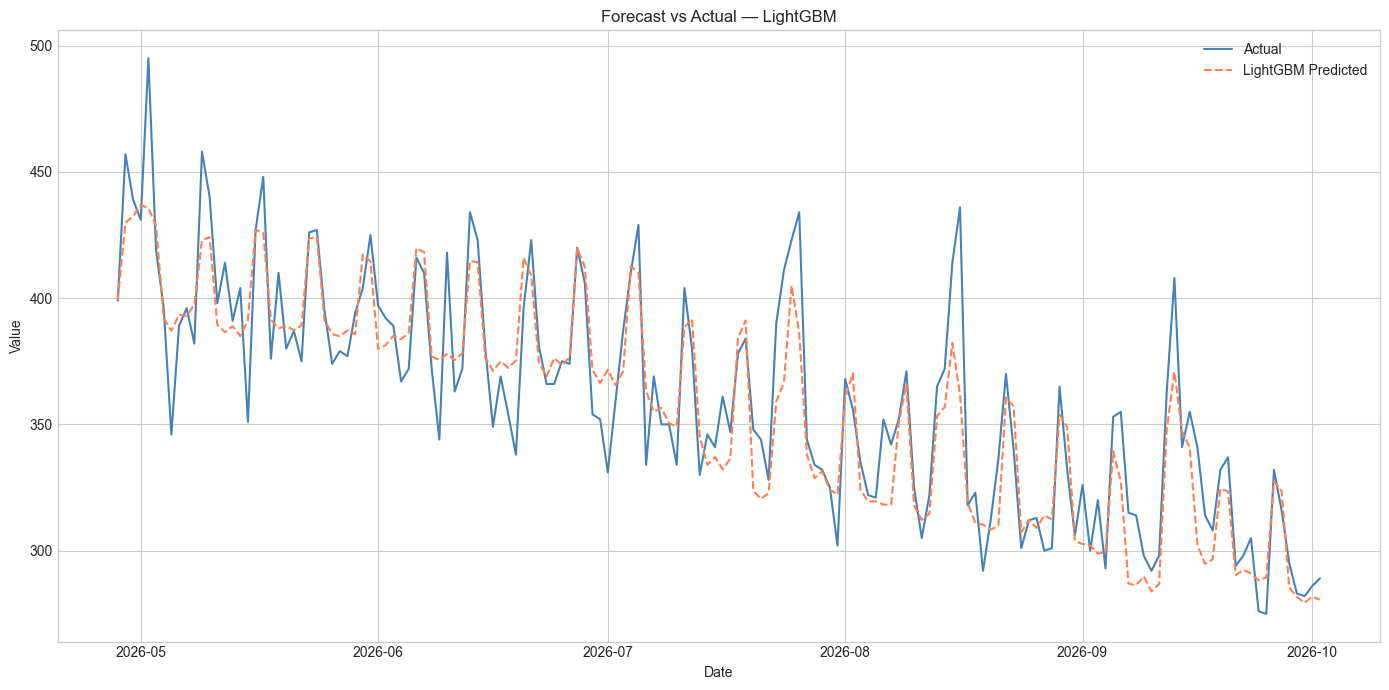

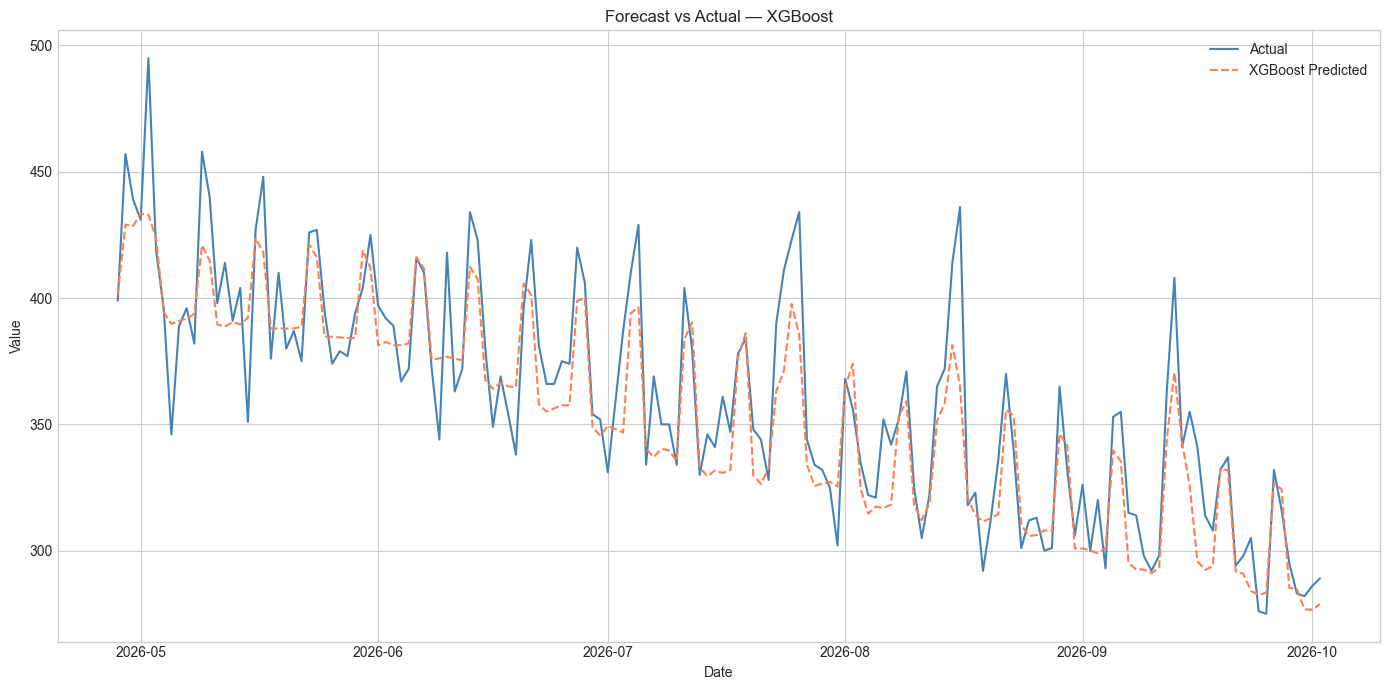

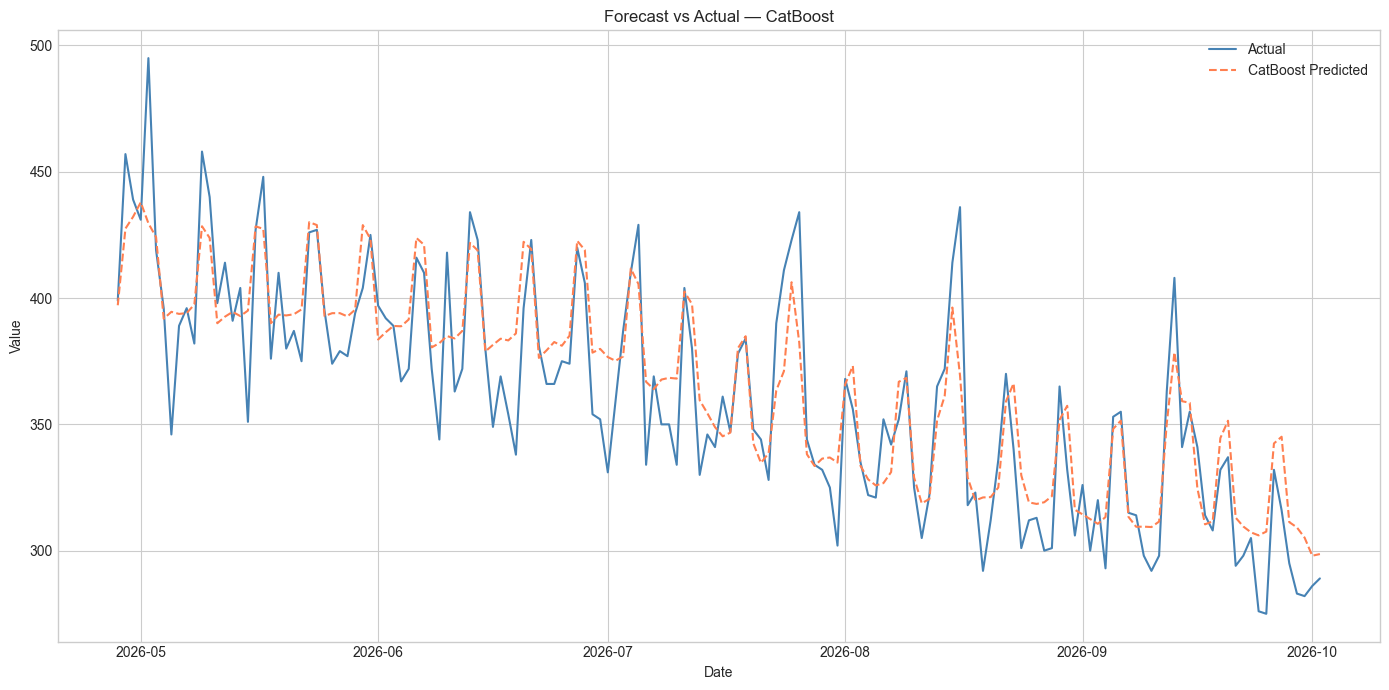

In [27]:
# Visualize ML forecasts (recursive multi-step)
for name, preds in [('LightGBM', lgbm_preds), ('XGBoost', xgb_preds), ('CatBoost', cat_preds)]:
    fig = eval_viz.plot_forecast(actuals_test, preds, dates=test_dates, model_name=name)
    plt.show()

---
## Section 6: Deep Learning Models

**Módulo `models/dl/`**

| Modelo | Enfoque | Veredicto honesto |
|---|---|---|
| **PatchTST** | Transformer con parches de 16 días; entrenado con split temporal interno; evaluado con pronóstico multi-ventana recursivo | Prometedor, pero con ~900 días de una serie tiene pocos ejemplos |
| **TimesFM** | Modelo fundacional de Google (zero-shot) | **Excluido en Windows** (requiere JAX/lingvo, Linux). Su fallback NO se reporta bajo su nombre — se reporta la ausencia |

**Lección de especialista**: la complejidad se gana con datos, no se presupone.

In [28]:
# --- TimesFM: availability check (honest exclusion) ---
try:
    import timesfm  # noqa: F401
    TIMESFM_AVAILABLE = True
    print("TimesFM available.")
except ImportError:
    TIMESFM_AVAILABLE = False
    print("TimesFM NOT available on this platform (requires Linux/JAX).")
    print("Excluded from the comparison — running its naive fallback under the")
    print("name 'TimesFM' would produce misleading numbers.")

TimesFM NOT available on this platform (requires Linux/JAX).
Excluded from the comparison — running its naive fallback under the
name 'TimesFM' would produce misleading numbers.


Training PatchTST (internal temporal split for early stopping)...


src.forecasting.models.dl.patchtst_model - INFO - Early stopping at epoch 9


src.forecasting.models.dl.patchtst_model - INFO - PatchTST fitted in 3.45 sec.


PatchTST: 158 recursive multi-window predictions


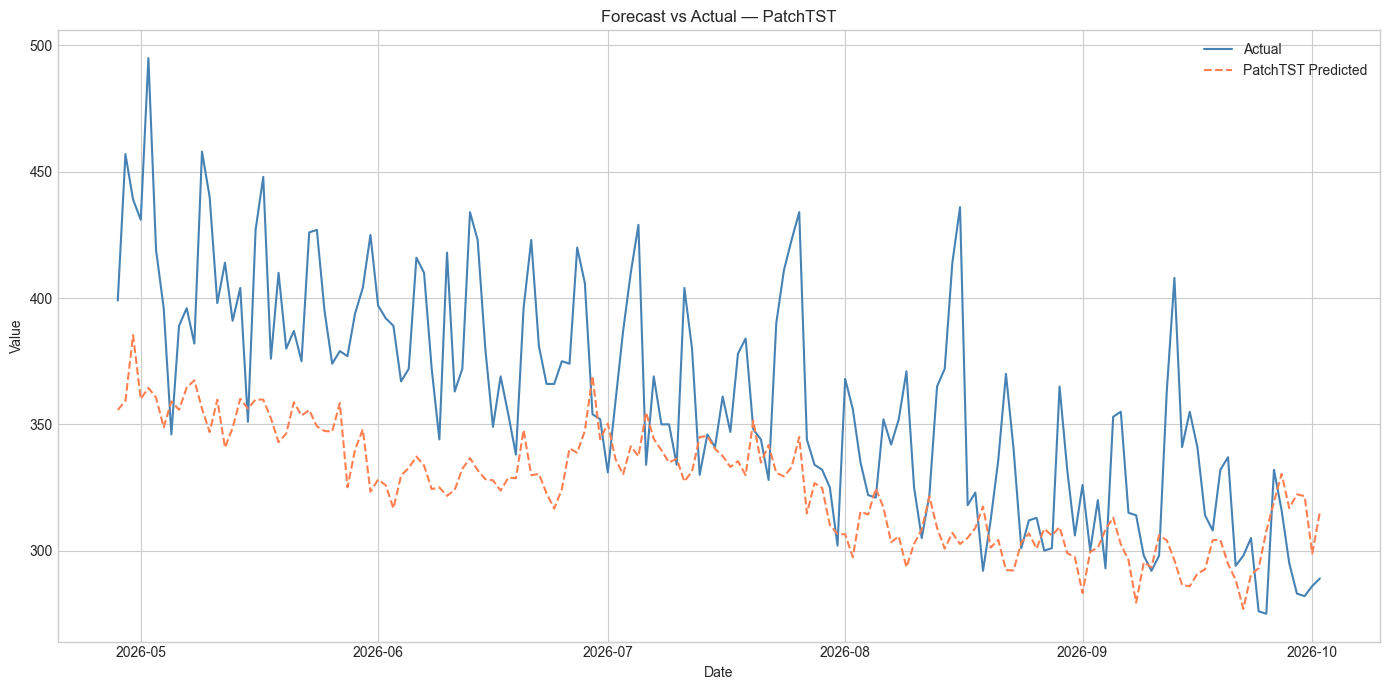

In [29]:
# --- PatchTST ---
print("Training PatchTST (internal temporal split for early stopping)...")
pt_cfg = CONFIG['models']['dl']['patchtst']
patchtst = PatchTSTForecaster(
    patch_len=pt_cfg['patch_len'], stride=pt_cfg['stride'],
    d_model=pt_cfg['d_model'], n_heads=pt_cfg['n_heads'],
    n_layers=pt_cfg['n_layers'], epochs=pt_cfg['epochs'],
    batch_size=pt_cfg['batch_size'], patience=pt_cfg['patience'],
    context_len=256, horizon=30,
)
n_val_pt = max(60, int(len(history_eval) * 0.10))
patchtst.fit(history_eval.iloc[:-n_val_pt][['date', TARGET_COL]],
             target_col=TARGET_COL, date_col='date',
             val_df=history_eval.iloc[-n_val_pt:][['date', TARGET_COL]])
patchtst_result = patchtst.predict(
    test_df, target_col=TARGET_COL, date_col='date',
    context_df=history_eval[['date', TARGET_COL]],
)
print(f"PatchTST: {len(patchtst_result.predictions)} recursive multi-window predictions")

fig = eval_viz.plot_forecast(actuals_test, patchtst_result.predictions, dates=test_dates,
                             model_name='PatchTST')
plt.show()

---
## Section 7: Final Comparison & Evaluation

**Módulo `evaluation/` — cómo leer la tabla**

**Guía de métricas:**
- **MAE** (room nights): error diario promedio — "me equivoqué en X habitaciones/día".
- **RMSE**: castiga errores grandes; RMSE >> MAE = días puntuales de desvío severo.
- **WAPE** (%): error total ÷ demanda total → "de cada 100 noches vendidas, me equivoqué en X".
- **MASE**: error ÷ error del naive estacional. **El juez más justo**: <1 supera al baseline.

**Rigor estadístico:** misma serie y ventana para todos; **Diebold-Mariano con varianza Newey-West (h=7)** compensa la autocorrelación de errores multi-paso; baseline SeasonalNaive incluido.
- **Backtesting rolling-origin** (Sección 7.5): estabilidad del ranking en 6 ventanas históricas — un solo split es una sola realización del azar.

**Nota de nomenclatura (alineada con Lighthouse):**
- **WAPE ≡ WMAPE** de la literatura hotelera — misma fórmula (`Σ|errores| ÷ Σ|reales| × 100`); pondera cada período por el volumen real.
- **MAPE** implementa exactamente `MAPE = (1/n) × Σ (|actual − pronóstico| ÷ actual) × 100`, con un placeholder mínimo (ε) cuando el real es cero — el fix que la propia guía recomienda para su pitfall de división por cero.
- **Cobertura**: MAPE, MAE, RMSE, WMAPE/WAPE, sMAPE (las 5 métricas de la guía) + **MASE** y **Bias%/días sobre-sub** que la guía no incluye.

In [30]:
# Evaluate all models on the SAME series and window
evaluator = Evaluator()

all_results = {
    'SeasonalNaive': (actuals_test, naive_preds),
    'Prophet': (actuals_test, prophet_result.predictions),
    'SARIMAX': (actuals_test, sarimax_result.predictions),
    'ETS': (actuals_test, ets_result.predictions),
    'LightGBM': (actuals_test, lgbm_preds),
    'XGBoost': (actuals_test, xgb_preds),
    'CatBoost': (actuals_test, cat_preds),
    'PatchTST': (actuals_test, patchtst_result.predictions),
}

metrics_results = evaluator.compute_all_metrics(
    all_results, split='test', naive_forecast=naive_preds
)
comparison_df = evaluator.comparison_table(metrics_results)
print("=== Model Comparison — Test Set (multi-step, room nights) ===")
display(comparison_df.round(2))

src.forecasting.evaluation.evaluator - INFO - SeasonalNaive (test): MAE=49.87, RMSE=60.32, MAPE=15.01%, WAPE=13.80%, Bias=+12.37% (135 over / 23 under)


src.forecasting.evaluation.evaluator - INFO - Prophet (test): MAE=31.31, RMSE=35.31, MAPE=9.09%, WAPE=8.66%, Bias=+7.14% (134 over / 24 under)


src.forecasting.evaluation.evaluator - INFO - SARIMAX (test): MAE=53.58, RMSE=64.83, MAPE=16.25%, WAPE=14.83%, Bias=+13.21% (133 over / 25 under)


src.forecasting.evaluation.evaluator - INFO - ETS (test): MAE=52.94, RMSE=63.31, MAPE=15.95%, WAPE=14.65%, Bias=+13.71% (146 over / 12 under)


src.forecasting.evaluation.evaluator - INFO - LightGBM (test): MAE=13.83, RMSE=18.42, MAPE=3.79%, WAPE=3.83%, Bias=-1.13% (63 over / 95 under)


src.forecasting.evaluation.evaluator - INFO - XGBoost (test): MAE=14.22, RMSE=18.77, MAPE=3.85%, WAPE=3.94%, Bias=-2.09% (55 over / 103 under)


src.forecasting.evaluation.evaluator - INFO - CatBoost (test): MAE=15.10, RMSE=19.62, MAPE=4.25%, WAPE=4.18%, Bias=+1.33% (96 over / 62 under)


src.forecasting.evaluation.evaluator - INFO - PatchTST (test): MAE=40.66, RMSE=50.52, MAPE=10.61%, WAPE=11.25%, Bias=-9.89% (27 over / 131 under)


=== Model Comparison — Test Set (multi-step, room nights) ===


,N,MAE,RMSE,MAPE,sMAPE,MASE,WAPE,Bias%,Over_days,Under_days
Model,,,,,,,,,,
SeasonalNaive,158,49.87,60.32,15.01,13.49,1.00,13.80,12.37,135,23
Prophet,158,31.31,35.31,9.09,8.63,0.63,8.66,7.14,134,24
SARIMAX,158,53.58,64.83,16.25,14.47,1.07,14.83,13.21,133,25
ETS,158,52.94,63.31,15.95,14.25,1.06,14.65,13.71,146,12
LightGBM,158,13.83,18.42,3.79,3.83,0.28,3.83,-1.13,63,95
XGBoost,158,14.22,18.77,3.85,3.92,0.29,3.94,-2.09,55,103
CatBoost,158,15.10,19.62,4.25,4.19,0.30,4.18,1.33,96,62
PatchTST,158,40.66,50.52,10.61,11.43,0.82,11.25,-9.89,27,131


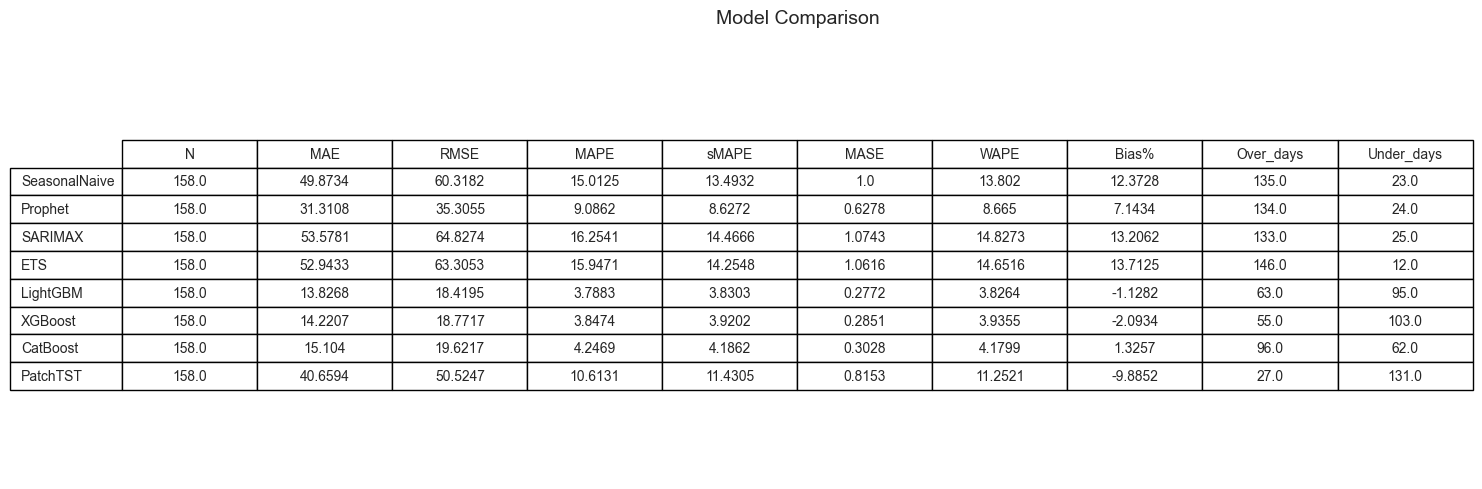

In [31]:
# Comparison visualization
fig = eval_viz.plot_comparison_table(comparison_df)
plt.show()

In [32]:
# Rank models by primary metric
comparison = evaluator.compare_models(metrics_results, primary_metric='MAE')
print(f"\nBest model (by MAE): {comparison.best_model}")
print(f"\nRankings by MAE: {comparison.rankings.get('MAE', [])}")

src.forecasting.evaluation.evaluator - INFO - Best model by MAE: LightGBM



Best model (by MAE): LightGBM

Rankings by MAE: ['LightGBM', 'XGBoost', 'CatBoost', 'Prophet', 'PatchTST', 'SeasonalNaive', 'ETS', 'SARIMAX']


In [33]:
# --- Direction (bias) & per-day-of-week diagnostics ---
# Lighthouse guidance: MAPE/WAPE carry magnitude but not DIRECTION. A forecast
# can be accurate AND systematically pessimistic (lost revenue) or optimistic
# (overstaffing, discounting). Segment breakdown localizes the weakness.
best_name = comparison.best_model
preds_best = all_results[best_name][1]  # self-contained
best_row = comparison_df.loc[best_name]
over, under = int(best_row['Over_days']), int(best_row['Under_days'])
direction = 'OVER-forecasts' if best_row['Bias%'] > 0 else 'UNDER-forecasts'
print(f"Bias del ganador ({best_name}): {best_row['Bias%']:+.2f}% -> {direction} "
      f"({over} dias sobre / {under} dias bajo)")
print("Regla practica: |Bias%| < 2% es neutro; > 5% exige ajuste operativo.")

err_df = pd.DataFrame({
    'date': test_dates, 'actual': actuals_test, 'pred': preds_best,
})
err_df['error'] = err_df['actual'] - err_df['pred']              # >0 = sub-pronostico
err_df['abs_error'] = err_df['error'].abs()
err_df['pct_error'] = err_df['abs_error'] / err_df['actual'] * 100
err_df['dow'] = err_df['date'].dt.day_name()

dow_table = err_df.groupby('dow').agg(
    days=('error', 'size'),
    MAE=('abs_error', 'mean'),
    MAPE_pct=('pct_error', 'mean'),
    signed_bias=('error', lambda e: float(-e.mean())),  # >0 = over-forecast
).reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

print("\n=== Errores por dia de la semana (diagnostico operativo) ===")
display(dow_table.round(2))
weekend_mae = err_df[err_df['date'].dt.dayofweek >= 5]['abs_error'].mean()
midweek_mae = err_df[err_df['date'].dt.dayofweek < 5]['abs_error'].mean()
print(f"\nMAE finde: {weekend_mae:.1f} vs entre-semana: {midweek_mae:.1f} room nights "
      f"({'finde peor -> revisar demanda de ocio/eventos' if weekend_mae > midweek_mae * 1.2 else 'sin brecha critica'})")

Bias del ganador (LightGBM): -1.13% -> UNDER-forecasts (63 dias sobre / 95 dias bajo)
Regla practica: |Bias%| < 2% es neutro; > 5% exige ajuste operativo.

=== Errores por dia de la semana (diagnostico operativo) ===


,days,MAE,MAPE_pct,signed_bias
dow,,,,
Monday,22,10.49,3.05,-1.78
Tuesday,23,14.49,4.14,-3.03
Wednesday,23,11.40,3.22,-2.44
Thursday,23,12.34,3.54,-4.42
Friday,23,16.48,4.76,1.23
Saturday,22,13.53,3.26,-9.35
Sunday,22,18.08,4.51,-9.09



MAE finde: 15.8 vs entre-semana: 13.1 room nights (finde peor -> revisar demanda de ocio/eventos)


In [34]:
# Diebold-Mariano: best model vs each competitor (Newey-West h=7)
ranked = comparison.rankings.get('MAE', [])
model_a = ranked[0]
print(f"DM tests (best by MAE): {model_a} vs each competitor")

dm_rows = []
for other in ranked[1:]:
    dm = evaluator.diebold_mariano_test(
        actuals_test, all_results[model_a][1], all_results[other][1], h=7, power=1
    )
    dm_rows.append({
        'Competitor': other,
        'DM': dm['dm_statistic'],
        'p-value': dm['p_value'],
        'Better & significant': bool(dm['significant'] and dm['dm_statistic'] < 0),
    })
dm_df = pd.DataFrame(dm_rows).set_index('Competitor')
display(dm_df)

src.forecasting.evaluation.evaluator - INFO - DM test: stat=-0.7715, p=0.4416 — Not significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-1.2322, p=0.2197 — Not significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-7.7638, p=0.0000 — Significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-9.5913, p=0.0000 — Significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-5.6871, p=0.0000 — Significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-5.8751, p=0.0000 — Significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-6.2728, p=0.0000 — Significant


DM tests (best by MAE): LightGBM vs each competitor


,DM,p-value,Better & significant
Competitor,,,
XGBoost,-0.7715,0.4416,False
CatBoost,-1.2322,0.2197,False
Prophet,-7.7638,0.0000,True
PatchTST,-9.5913,0.0000,True
SeasonalNaive,-5.6871,0.0000,True
ETS,-5.8751,0.0000,True
SARIMAX,-6.2728,0.0000,True


In [35]:
# Residual diagnostics for best model
best_name = comparison.best_model
actuals_best, preds_best = all_results[best_name]
diag = evaluator.residual_diagnostics(actuals_best, preds_best)
print(f"\nResidual Diagnostics — {best_name}:")
for test_name, result in diag.items():
    print(f"  {test_name}: {result}")

src.forecasting.evaluation.evaluator - INFO - Residual diagnostics: JB p=0.0001, LB min_p=0.0085



Residual Diagnostics — LightGBM:
  jarque_bera: {'statistic': 18.6578, 'p_value': 0.0001}
  ljung_box: {'min_p_value': 0.0085}
  breusch_pagan: {'statistic': 0.3745, 'p_value': 0.5406}
  residual_mean: 4.0766
  residual_std: 17.9627


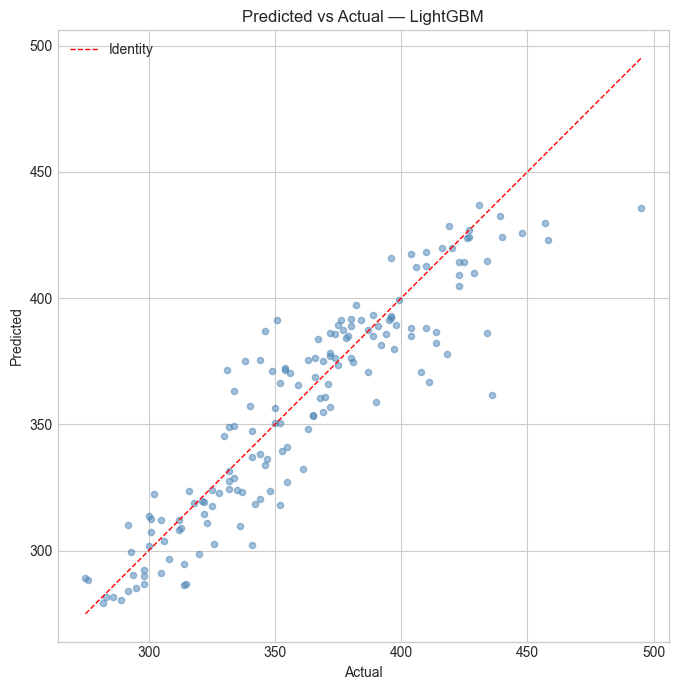

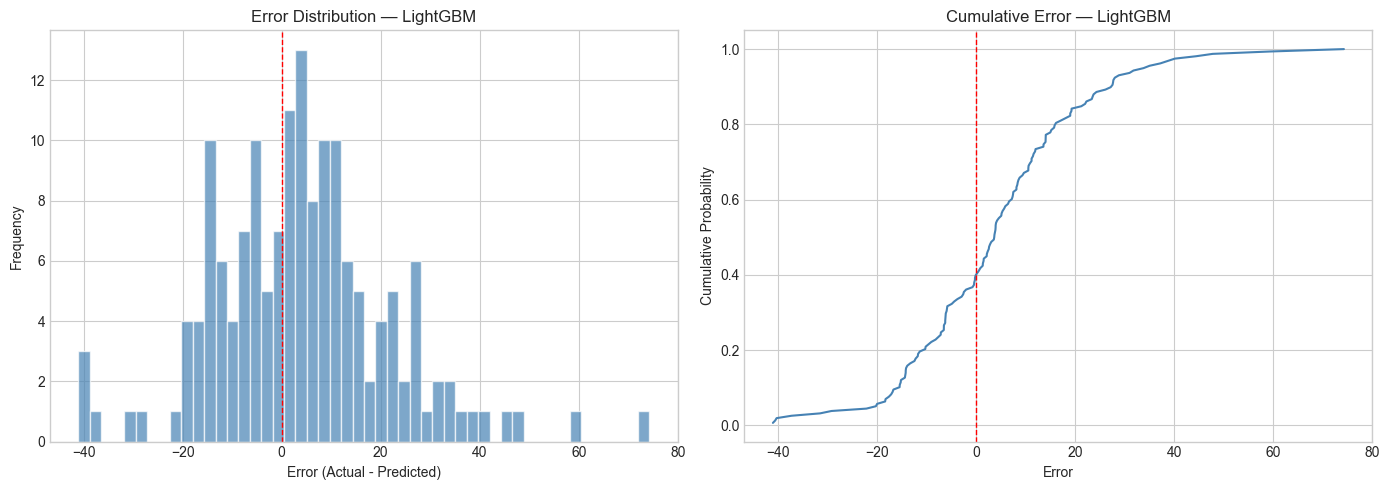

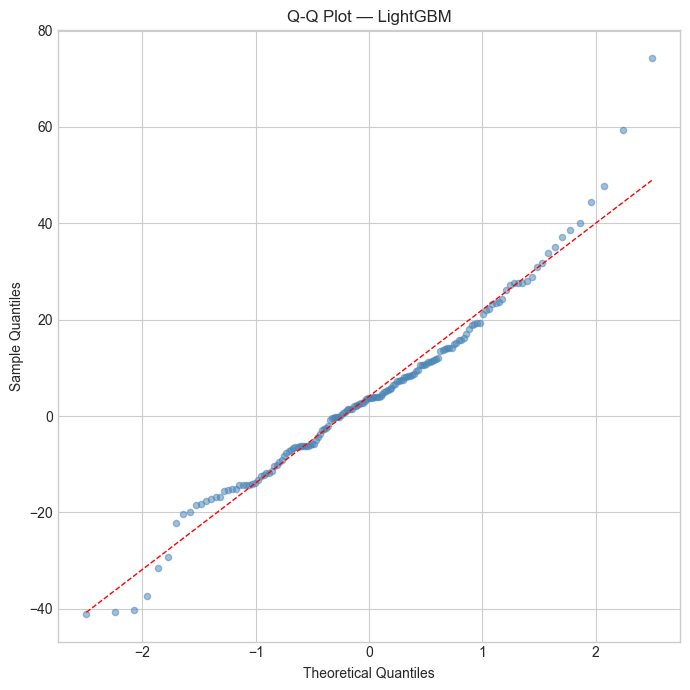

In [36]:
# Scatter and error distribution for best model
fig = eval_viz.plot_scatter(actuals_best, preds_best, model_name=best_name)
plt.show()

fig = eval_viz.plot_error_distribution(actuals_best, preds_best, model_name=best_name)
plt.show()

fig = eval_viz.plot_qq(actuals_best, preds_best, model_name=best_name)
plt.show()

---
### Section 7.5: Rolling-Origin Backtesting — estabilidad del ranking

Un solo split de test es UNA realización del azar: ventanas distintas podrían
reordenar modelos. Cada fold del backtest recibe **solo historia estrictamente
anterior a su ventana** (misma regla anti-fuga), con hiperparámetros congelados
de la fase de tuning — se mide estabilidad, no se re-selecciona.

Los residuales por paso del ganador alimentan además las bandas conformales
de la Sección 8.

In [37]:
# --- Rolling-origin backtesting: 6 windows x 90 days ---
from src.forecasting.evaluation.backtesting import make_rolling_folds, rolling_origin_backtest

BT_HORIZON = CONFIG['forecasting']['horizon_days']  # 90: matches the forecast horizon
bt_folds = make_rolling_folds(
    test_start - pd.Timedelta(days=1), n_folds=6, horizon_days=BT_HORIZON, step_days=45,
)
print(f"Backtest: {len(bt_folds)} ventanas de {BT_HORIZON}d | "
      f"origenes: {[str(f.window_start.date()) for f in bt_folds]}")

def _bt_stat_forecaster(cls, **kw):
    def f(hist, dates):
        m = cls(**kw)
        m.fit(hist[['date', TARGET_COL]], target_col=TARGET_COL, date_col='date')
        return m.predict(pd.DataFrame({'date': dates}), target_col=TARGET_COL,
                         date_col='date').predictions
    return f

def _bt_gbm(cls, params, iters_key, iters):
    def f(hist, dates):
        m = cls(params={**params, iters_key: int(iters)}, early_stopping_rounds=50)
        m.fit(prepare_features(hist), target_col=TARGET_COL, date_col='date',
              feature_cols=feature_cols_ml)
        return recursive_forecast(
            m, hist, dates, target_col=TARGET_COL, date_col='date',
            feature_cols=feature_cols_ml,
            feature_engineer=pipeline.feature_engineer,
            holiday_engineer=pipeline.holiday_engineer,
            future_known_cols=FUTURE_KNOWN,
        )
    return f

def _bt_patchtst(hist, dates):
    m = PatchTSTForecaster(
        patch_len=pt_cfg['patch_len'], stride=pt_cfg['stride'],
        d_model=pt_cfg['d_model'], n_heads=pt_cfg['n_heads'],
        n_layers=pt_cfg['n_layers'], epochs=pt_cfg['epochs'],
        batch_size=pt_cfg['batch_size'], patience=pt_cfg['patience'],
        context_len=256, horizon=30,
    )
    h = hist[['date', TARGET_COL]]
    nv = max(60, int(len(h) * 0.10))
    m.fit(h.iloc[:-nv], target_col=TARGET_COL, date_col='date', val_df=h.iloc[-nv:])
    return m.predict(pd.DataFrame({'date': dates}), target_col=TARGET_COL,
                     date_col='date', context_df=h).predictions

def _bt_naive(hist, dates):
    tail = hist[TARGET_COL].values[-7:]
    return np.array([tail[i % 7] for i in range(len(dates))])

bt_forecasters = {
    'SeasonalNaive': _bt_naive,
    'Prophet': _bt_stat_forecaster(ProphetForecaster, **prophet_best),
    'SARIMAX': _bt_stat_forecaster(
        SARIMAXForecaster,
        seasonal_periods=CONFIG['models']['statistical']['sarimax']['seasonal_periods'],
        stepwise=True,
    ),
    'ETS': _bt_stat_forecaster(ETSForecaster, seasonal_periods=7, damped_trend=True, auto_select=True),
    'LightGBM': _bt_gbm(LightGBMForecaster, lgbm_params, 'n_estimators', getattr(lgbm, 'frozen_iteration', 1000)),
    'XGBoost': _bt_gbm(XGBoostForecaster, xgb_params, 'n_estimators', getattr(xgb, 'frozen_iteration', 1000)),
    'CatBoost': _bt_gbm(CatBoostForecaster, cat_params, 'iterations', getattr(cat, 'frozen_iteration', 1000)),
    'PatchTST': _bt_patchtst,
}

bt_result = rolling_origin_backtest(df_agg, bt_forecasters, bt_folds, target_col=TARGET_COL)

print("=== MAE (room nights) por ventana de backtest ===")
display(bt_result.mae_table.round(1))
print("\n=== Estabilidad de ranking (rango medio, 1 = mejor) ===")
display(pd.DataFrame({'rango_medio': bt_result.mean_rank, 'victorias': bt_result.wins}))
print(f"\nGanador del test ({best_name}): rango medio "
      f"{bt_result.mean_rank[best_name]:.1f}/8 | {int(bt_result.wins[best_name])}/{len(bt_folds)} victorias")

cmdstanpy - DEBUG - cmd: where.exe tbb.dll
cwd: None


cmdstanpy - DEBUG - TBB already found in load path


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmpt5ogn7tv\0jzmvn0y.json


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmpt5ogn7tv\uywh7fje.json


cmdstanpy - DEBUG - idx 0


...

=== MAE (room nights) por ventana de backtest ===


fold,0,1,2,3,4,5
SeasonalNaive,32.9,47.9,24.5,40.8,48.1,45.6
Prophet,23.2,26.7,33.1,19.0,15.1,17.8
SARIMAX,43.4,38.4,17.8,39.5,48.5,40.5
ETS,33.8,34.3,33.8,37.1,47.4,38.9
LightGBM,12.2,14.1,16.1,16.3,14.9,16.3
XGBoost,13.4,14.0,15.5,16.5,14.9,18.9
CatBoost,12.5,11.8,14.8,15.5,16.7,25.2
PatchTST,31.6,27.6,27.4,33.7,25.8,36.0



=== Estabilidad de ranking (rango medio, 1 = mejor) ===


,rango_medio,victorias
CatBoost,2.166667,3
ETS,6.500000,0
LightGBM,1.833333,3
PatchTST,5.166667,0
Prophet,4.000000,0
SARIMAX,6.833333,0
SeasonalNaive,7.000000,0
XGBoost,2.500000,0



Ganador del test (LightGBM): rango medio 1.8/8 | 3/6 victorias


---
## Section 8: Future Forecast

**Práctica estándar post-selección**: el modelo ganador se **reentrena con TODA la historia observada** y pronostica los próximos 90 días con la misma mecánica honesta (recursiva para ML, `available_rooms` forward-known).

**Novedad room nights — techo de capacidad:**
- El pronóstico se **recorta a la capacidad disponible** (`available_rooms`, portafolio = suma de hoteles).
- Se reporta la **ocupación implícita** (pronóstico ÷ capacidad) y los días recortados.
- Capacidad futura = último valor observado (suposición documentada: sin renovaciones anunciadas).
- **Bandas conformales P10/P90** por paso de horizonte, construidas con los residuales del backtesting del ganador — la incertidumbre crece con el horizonte y la banda lo refleja.
- **Por hotel**: evaluación y pronóstico per-hotel para staffing; la suma per-hotel se compara con el pronóstico directo del portafolio (sin reconciliación jerarquica, documentado).

In [38]:
# ------------------------------------------------------------------
# FUTURE FORECAST: best model retrained on ALL observed data
# ------------------------------------------------------------------
horizon = CONFIG['forecasting']['horizon_days']
last_observed = full_history['date'].max()
future_dates = pd.date_range(last_observed + pd.Timedelta(days=1), periods=horizon, freq='D')
future_df = pd.DataFrame({'date': future_dates})

# Future capacity = last observed (documented assumption)
last_capacity = float(full_history[AVAIL_COL].iloc[-1])
future_capacity = pd.Series(np.full(horizon, last_capacity))

print(f"Best model: {best_name} | Forecasting {horizon} days from {future_dates[0].date()}")
print(f"Future capacity (last observed): {last_capacity:.0f} rooms/day")

future_lo = future_hi = None

gbm_map = {'LightGBM': lgbm, 'XGBoost': xgb, 'CatBoost': cat}

if best_name in gbm_map:
    model_obj = gbm_map[best_name]
    full_feat = pipeline.feature_engineer.transform(full_history)
    full_feat = pipeline.holiday_engineer.transform(full_feat)
    full_feat = pipeline.outlier_handler.transform(full_feat)
    model_obj.final_refit(full_feat, target_col=TARGET_COL, date_col='date',
                          feature_cols=feature_cols_ml)
    raw_future = recursive_forecast(
        model_obj, full_history, future_dates,
        target_col=TARGET_COL, date_col='date',
        feature_cols=feature_cols_ml,
        feature_engineer=pipeline.feature_engineer,
        holiday_engineer=pipeline.holiday_engineer,
        future_known_cols=FUTURE_KNOWN,
    )
elif best_name == 'SeasonalNaive':
    last_week_full = full_history[TARGET_COL].values[-7:]
    raw_future = np.array([last_week_full[i % 7] for i in range(horizon)])
elif best_name == 'Prophet':
    final_model = ProphetForecaster(
        changepoint_prior_scale=prophet_best['changepoint_prior_scale'],
        seasonality_prior_scale=prophet_best['seasonality_prior_scale'],
    )
    final_model.fit(full_history, target_col=TARGET_COL, date_col='date')
    fr = final_model.predict(future_df, target_col=TARGET_COL, date_col='date')
    raw_future, future_lo, future_hi = fr.predictions, fr.lower_bound, fr.upper_bound
elif best_name == 'SARIMAX':
    final_model = SARIMAXForecaster(
        seasonal_periods=CONFIG['models']['statistical']['sarimax']['seasonal_periods'],
        stepwise=CONFIG['models']['statistical']['sarimax']['stepwise'],
    )
    final_model.fit(full_history, target_col=TARGET_COL, date_col='date')
    fr = final_model.predict(future_df, target_col=TARGET_COL, date_col='date')
    raw_future, future_lo, future_hi = fr.predictions, fr.lower_bound, fr.upper_bound
elif best_name == 'ETS':
    final_model = ETSForecaster(seasonal_periods=7, damped_trend=True, auto_select=True)
    final_model.fit(full_history, target_col=TARGET_COL, date_col='date')
    fr = final_model.predict(future_df, target_col=TARGET_COL, date_col='date')
    raw_future, future_lo, future_hi = fr.predictions, fr.lower_bound, fr.upper_bound
elif best_name == 'PatchTST':
    final_model = PatchTSTForecaster(
        patch_len=pt_cfg['patch_len'], stride=pt_cfg['stride'],
        d_model=pt_cfg['d_model'], n_heads=pt_cfg['n_heads'],
        n_layers=pt_cfg['n_layers'], epochs=pt_cfg['epochs'],
        batch_size=pt_cfg['batch_size'], patience=pt_cfg['patience'],
        context_len=256, horizon=30,
    )
    n_val_f = max(60, int(len(full_history) * 0.10))
    final_model.fit(full_history.iloc[:-n_val_f][['date', TARGET_COL]],
                    target_col=TARGET_COL, date_col='date',
                    val_df=full_history.iloc[-n_val_f:][['date', TARGET_COL]])
    fr = final_model.predict(future_df, target_col=TARGET_COL, date_col='date',
                             context_df=full_history[['date', TARGET_COL]])
    raw_future = fr.predictions

assert len(raw_future) == horizon and not np.isnan(np.asarray(raw_future, dtype=float)).any()

# --- Capacity ceiling + implied occupancy ---
future_series = pd.Series(np.asarray(raw_future, dtype=float), index=future_dates)
future_preds, cap_report = apply_capacity_ceiling(future_series, future_capacity)
future_occ = implied_occupancy(future_preds, future_capacity)

print(f"\nTotal forecasted room nights ({horizon}d): {future_preds.sum():,.0f}")
print(f"Daily mean: {future_preds.mean():,.1f} room nights")
print(f"Implied occupancy: mean={future_occ.mean():.1%} | max={future_occ.max():.1%}")
print(f"Days capped by capacity: {len(cap_report)}")

src.forecasting.preprocessing.features - INFO - Feature engineering complete: 44 columns


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.preprocessing.outliers - INFO - Outliers in 'rooms_sold': 4 (0.37%) — action: flag


src.forecasting.preprocessing.outliers - INFO - Outliers in 'available_rooms': 42 (3.84%) — action: flag


Best model: LightGBM | Forecasting 90 days from 2026-10-03
Future capacity (last observed): 550 rooms/day


...

src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.forecasting.recursive - INFO - Incremental path verified (46 feature columns match the reference).


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 50/90 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast complete: 90 steps (incremental path)



Total forecasted room nights (90d): 27,169
Daily mean: 301.9 room nights
Implied occupancy: mean=54.9% | max=66.8%
Days capped by capacity: 0


In [39]:
# --- Conformal uncertainty bands (empirical, per horizon step) ---
from src.forecasting.evaluation.conformal import (
    per_horizon_conformal_bands, empirical_coverage, summarize_bands,
)

ALPHA = 0.2  # nominal 80% bands (P10/P90)
bt_res_matrix = bt_result.residuals[best_name]  # (n_folds, horizon) signed residuals
assert bt_res_matrix.shape[1] == horizon, "backtest horizon must match forecast horizon"

lo_future, hi_future = per_horizon_conformal_bands(bt_res_matrix, future_preds.values, alpha=ALPHA)
lo_future = np.maximum(lo_future, 0.0)                      # room nights >= 0
hi_future = np.minimum(hi_future, future_capacity.values)  # physical ceiling

# Empirical coverage on the first `horizon` days of the test window
winner_test_preds = all_results[best_name][1][:horizon]
test_lo, test_hi = per_horizon_conformal_bands(bt_res_matrix, winner_test_preds, alpha=ALPHA)
test_coverage = empirical_coverage(actuals_test[:horizon], test_lo, test_hi)

print(f"Banda {int((1 - ALPHA) * 100)}% conformal ({bt_res_matrix.shape[0]} ventanas de backtest):")
print(f"  Total {horizon}d: {lo_future.sum():,.0f} – {hi_future.sum():,.0f} room nights "
      f"(punto: {future_preds.sum():,.0f})")
print(f"  Ancho medio: dia 1 = {hi_future[0] - lo_future[0]:.1f} | "
      f"dia {horizon} = {hi_future[-1] - lo_future[-1]:.1f} (crece con el horizonte)")
print(f"  Cobertura empirica en test ({horizon}d): {test_coverage:.0%} "
      f"vs nominal {1 - ALPHA:.0%}")

future_lo, future_hi = lo_future, hi_future  # consumidos por el plot y conclusiones
bands_df = summarize_bands(future_dates, future_preds.values, lo_future, hi_future, name=TARGET_COL)
display(bands_df.head(10).round(1))

src.forecasting.evaluation.conformal - INFO - Conformal bands (alpha=0.20): mean width=33.50 | step-1 width=31.11 | final-step width=25.39


src.forecasting.evaluation.conformal - INFO - Conformal bands (alpha=0.20): mean width=33.50 | step-1 width=31.11 | final-step width=25.39


Banda 80% conformal (6 ventanas de backtest):
  Total 90d: 26,435 – 29,450 room nights (punto: 27,169)
  Ancho medio: dia 1 = 31.1 | dia 90 = 25.4 (crece con el horizonte)
  Cobertura empirica en test (90d): 60% vs nominal 80%


,date,rooms_sold,lower,upper,width
0,2026-10-03,327.4,304.8,335.9,31.1
1,2026-10-04,321.1,307.7,347.4,39.7
2,2026-10-05,276.3,261.1,284.8,23.8
3,2026-10-06,282.1,275.3,300.1,24.8
4,2026-10-07,279.5,273.5,299.8,26.3
5,2026-10-08,272.9,260.2,280.0,19.8
6,2026-10-09,280.8,260.9,301.4,40.5
7,2026-10-10,337.5,328.4,364.6,36.2
8,2026-10-11,332.0,328.7,349.6,20.9
9,2026-10-12,287.0,280.7,320.6,39.9


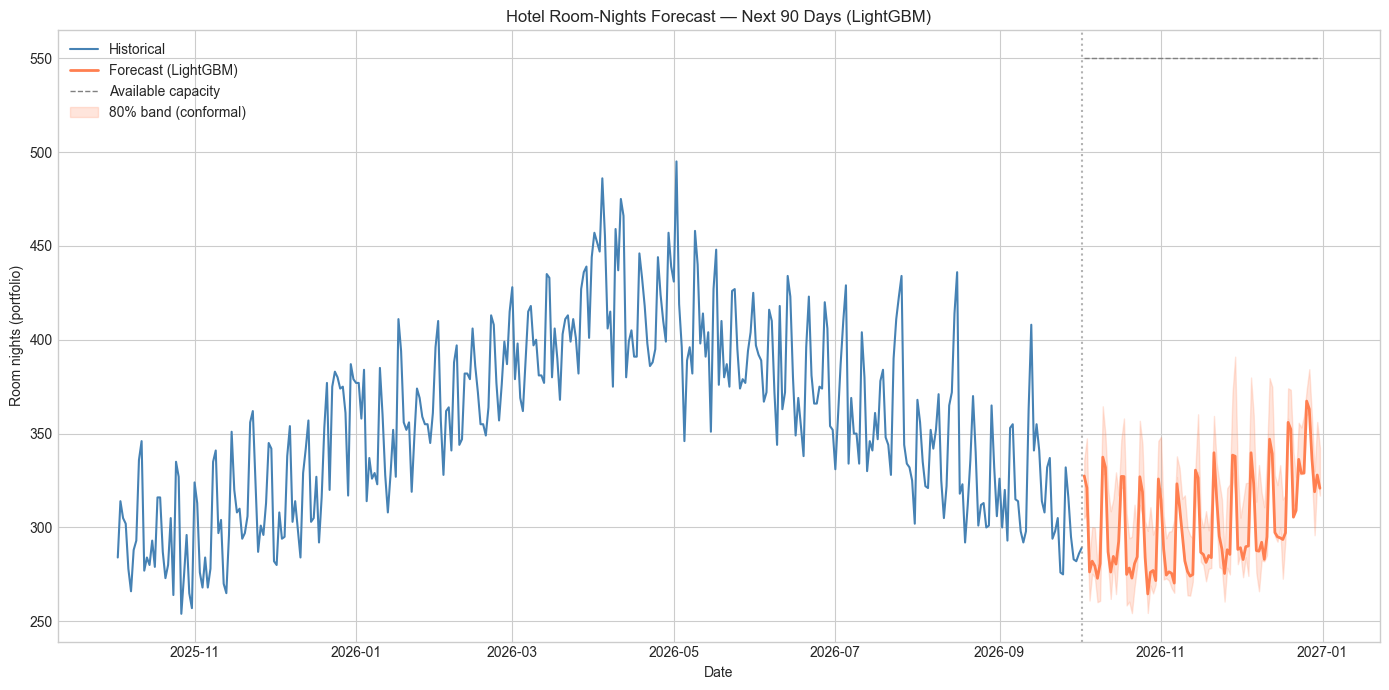

In [40]:
# Plot future forecast with capacity ceiling
fig, ax = plt.subplots(figsize=(14, 7))
hist_plot = full_history.iloc[-365:]
ax.plot(hist_plot['date'], hist_plot[TARGET_COL], label='Historical', color='steelblue', linewidth=1.5)
ax.plot(future_dates, future_preds.values, label=f'Forecast ({best_name})', color='coral', linewidth=2)
ax.plot(future_dates, future_capacity, label='Available capacity', color='gray',
        linestyle='--', linewidth=1)
if future_lo is not None:
    ax.fill_between(future_dates, future_lo, future_hi, alpha=0.2, color='coral', label=f'{int((1 - ALPHA) * 100)}% band (conformal)')
ax.axvline(x=last_observed, color='gray', linestyle=':', alpha=0.6)
ax.set_title(f'Hotel Room-Nights Forecast — Next {horizon} Days ({best_name})')
ax.set_xlabel('Date')
ax.set_ylabel('Room nights (portfolio)')
ax.legend()
fig.tight_layout()
plt.show()

---
### Section 8.5: Per-hotel evaluation & forecast (para staffing operativo)

Operaciones hace staffing **por hotel**, no por portafolio. Se re-entrena el
modelo ganador por hotel (mismos hiperparámetros congelados, misma historia
pre-test por hotel) y se evalúa en la misma ventana de test. La suma de los
pronósticos por hotel se compara contra el pronóstico directo del portafolio —
**sin reconciliación jerárquica** (documentado como no-goal); la diferencia
mide el costo de agregar la señal.

In [41]:
# --- Per-hotel evaluation & 90-day forecast ---
ops_raw = df[df[TARGET_COL].notna()][['date', 'hotel_id', TARGET_COL, AVAIL_COL]]

per_hotel_eval_rows = []
per_hotel_future = []

if best_name not in gbm_map and best_name not in ('Prophet', 'SARIMAX', 'ETS'):
    print(f"Winner {best_name}: per-hotel forecast no implementado para esta familia; "
          "se documenta y se omite (ver design.md).")
    per_hotel_eval_df = None
else:
    stat_map = {'Prophet': (ProphetForecaster, prophet_best),
                'SARIMAX': (SARIMAXForecaster,
                            {'seasonal_periods': CONFIG['models']['statistical']['sarimax']['seasonal_periods'],
                             'stepwise': True}),
                'ETS': (ETSForecaster, {'seasonal_periods': 7, 'damped_trend': True, 'auto_select': True})}
    for hotel in sorted(ops_raw['hotel_id'].unique()):
        h_raw = (ops_raw[ops_raw['hotel_id'] == hotel]
                 .groupby('date', as_index=False).sum(min_count=1)
                 .sort_values('date'))
        full_idx = pd.date_range(h_raw['date'].min(), h_raw['date'].max(), freq='D')
        h = h_raw.set_index('date').reindex(full_idx).reset_index(names='date')
        h = pipeline.missing_handler.fit_transform(h)  # fill gaps before modeling

        h_hist = h[h['date'] < test_start]
        h_full = h
        h_test_actuals = h.loc[h['date'] >= test_start, TARGET_COL].values

        if best_name in gbm_map:
            cls = {'LightGBM': LightGBMForecaster, 'XGBoost': XGBoostForecaster, 'CatBoost': CatBoostForecaster}[best_name]
            params = {'LightGBM': lgbm_params, 'XGBoost': xgb_params, 'CatBoost': cat_params}[best_name]
            iters_key = 'iterations' if best_name == 'CatBoost' else 'n_estimators'
            iters = gbm_map[best_name].frozen_iteration

            m = cls(params={**params, iters_key: int(iters)}, early_stopping_rounds=50)
            m.fit(prepare_features(h_hist), target_col=TARGET_COL, date_col='date',
                  feature_cols=feature_cols_ml)
            preds_test_h = recursive_forecast(
                m, h_hist, test_dates, target_col=TARGET_COL, date_col='date',
                feature_cols=feature_cols_ml,
                feature_engineer=pipeline.feature_engineer,
                holiday_engineer=pipeline.holiday_engineer,
                future_known_cols=FUTURE_KNOWN,
            )
            m = cls(params={**params, iters_key: int(iters)}, early_stopping_rounds=50)
            m.fit(prepare_features(h_full), target_col=TARGET_COL, date_col='date',
                  feature_cols=feature_cols_ml)
            preds_future_h = recursive_forecast(
                m, h_full, future_dates, target_col=TARGET_COL, date_col='date',
                feature_cols=feature_cols_ml,
                feature_engineer=pipeline.feature_engineer,
                holiday_engineer=pipeline.holiday_engineer,
                future_known_cols=FUTURE_KNOWN,
            )
        else:
            cls, kw = stat_map[best_name]
            m = cls(**kw)
            m.fit(h_hist[['date', TARGET_COL]], target_col=TARGET_COL, date_col='date')
            preds_test_h = m.predict(
                pd.DataFrame({'date': test_dates}), target_col=TARGET_COL, date_col='date'
            ).predictions
            m = cls(**kw)
            m.fit(h_full[['date', TARGET_COL]], target_col=TARGET_COL, date_col='date')
            preds_future_h = m.predict(
                pd.DataFrame({'date': future_dates}), target_col=TARGET_COL, date_col='date'
            ).predictions

        res_h = evaluator.compute_metrics(h_test_actuals, preds_test_h, model_name=hotel)
        per_hotel_eval_rows.append({
            'hotel': hotel, 'MAE': res_h.metrics['MAE'],
            'WAPE': res_h.metrics['WAPE'], 'Bias%': res_h.metrics['Bias%'],
        })

        cap_h = float(h_full[AVAIL_COL].iloc[-1])
        f_series = pd.Series(np.asarray(preds_future_h, dtype=float), index=future_dates)
        capped_h, _ = apply_capacity_ceiling(f_series, pd.Series(np.full(horizon, cap_h)))
        per_hotel_future.append(pd.DataFrame({
            'hotel': hotel, 'date': future_dates,
            'forecast': capped_h.values, 'capacity': cap_h,
        }))

    per_hotel_eval_df = pd.DataFrame(per_hotel_eval_rows).set_index('hotel')
    print("=== Evaluacion per-hotel del ganador (test window) ===")
    display(per_hotel_eval_df.round(2))

    per_hotel_fc = pd.concat(per_hotel_future, ignore_index=True)
    ph_daily = per_hotel_fc.groupby('date')['forecast'].sum()
    ph_total = float(ph_daily.sum())
    print(f"\nSuma per-hotel {horizon}d: {ph_total:,.0f} vs portafolio directo: "
          f"{future_preds.sum():,.0f} ({(ph_total / future_preds.sum() - 1) * 100:+.1f}%)")
    print("(Sin reconciliacion jerarquica: la diferencia mide el costo de agregar la senal)")

    occ_h = (per_hotel_fc.groupby('hotel')['forecast'].sum()
             / (per_hotel_fc.groupby('hotel')['capacity'].first() * horizon))
    print("\n=== Ocupacion implícita 90d por hotel ===")
    display(occ_h.to_frame('ocupacion_90d').round(3))

src.forecasting.preprocessing.features - INFO - Feature engineering complete: 45 columns


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.preprocessing.outliers - INFO - Outliers in 'rooms_sold': 937 (100.00%) — action: flag


src.forecasting.preprocessing.outliers - INFO - Outliers in 'available_rooms': 937 (100.00%) — action: flag


src.forecasting.models.ml.lgbm_model - INFO - LightGBM fitted in 0.10 sec, best iteration: 0


...

src.forecasting.evaluation.evaluator - INFO - HOTEL_005 (test): MAE=4.96, RMSE=6.50, MAPE=6.04%, WAPE=6.18%, Bias=-3.69% (50 over / 108 under)


=== Evaluacion per-hotel del ganador (test window) ===


,MAE,WAPE,Bias%
hotel,,,
HOTEL_001,4.15,8.37,-6.01
HOTEL_002,9.79,7.59,0.81
HOTEL_003,3.87,6.61,-3.82
HOTEL_004,3.91,8.90,-4.22
HOTEL_005,4.96,6.18,-3.69



Suma per-hotel 90d: 27,411 vs portafolio directo: 27,169 (+0.9%)
(Sin reconciliacion jerarquica: la diferencia mide el costo de agregar la senal)

=== Ocupacion implícita 90d por hotel ===


,ocupacion_90d
hotel,
HOTEL_001,0.514
HOTEL_002,0.533
HOTEL_003,0.633
HOTEL_004,0.459
HOTEL_005,0.632


In [42]:
# Assumptions & Limitations (honest reporting)
print("=== Supuestos ===")
assumptions = [
    "Los patrones históricos de demanda (tendencia, estacionalidad, festivos CR) continúan.",
    "Sin choques externos mayores (eventos, crisis, cambios regulatorios).",
    f"Capacidad futura = último valor observado ({last_capacity:.0f} hab/día); sin renovaciones anunciadas.",
    "La operación hotelera se mantiene consistente con los datos observados.",
]
for i, a in enumerate(assumptions, 1):
    print(f"  {i}. {a}")

print("\n=== Limitaciones ===")
limitations = [
    "Datos sintéticos: las cifras validan la metodología, no son números de negocio.",
    "La incertidumbre crece con el horizonte (90 días es exigente).",
    "Sin datos forward-looking del PMS (pickup/reservas, bloques de grupos, tarifas planeadas).",
    "Sin datos exógenos (clima, vuelos, mercados emisores, competencia).",
    "Reentrenar periódicamente con datos nuevos y monitorear el error.",
]
for i, l in enumerate(limitations, 1):
    print(f"  {i}. {l}")

=== Supuestos ===
  1. Los patrones históricos de demanda (tendencia, estacionalidad, festivos CR) continúan.
  2. Sin choques externos mayores (eventos, crisis, cambios regulatorios).
  3. Capacidad futura = último valor observado (550 hab/día); sin renovaciones anunciadas.
  4. La operación hotelera se mantiene consistente con los datos observados.

=== Limitaciones ===
  1. Datos sintéticos: las cifras validan la metodología, no son números de negocio.
  2. La incertidumbre crece con el horizonte (90 días es exigente).
  3. Sin datos forward-looking del PMS (pickup/reservas, bloques de grupos, tarifas planeadas).
  4. Sin datos exógenos (clima, vuelos, mercados emisores, competencia).
  5. Reentrenar periódicamente con datos nuevos y monitorear el error.


---
## Section 9: Conclusions

**Marco de decisión aplicado:**
1. **¿Supera el naive?** MASE < 1 es requisito mínimo.
2. **¿La ventaja es estadísticamente real?** Diebold-Mariano con Newey-West.
3. **¿Es utilizable por el negocio?** WAPE < 10% en hotelería suele bastar para planificar personal, inventario y pricing.
4. **¿Es sostenible?** Monitoreo + reentrenamiento periódico.
5. **¿Es estable?** Backtesting rolling-origin — el ranking no puede depender de una sola ventana.

**Honestidad como política**: datos sintéticos declarados, TimesFM excluido en vez de fingido, advertencias junto a las cifras.

In [43]:
best_row = comparison_df.loc[best_name]
naive_row = comparison_df.loc['SeasonalNaive']
improvement = (1 - best_row['MAE'] / naive_row['MAE']) * 100

print("=" * 64)
print("     CONCLUSIONES — ROOM NIGHTS (protocolo honesto multi-paso)")
print("=" * 64)
print(f"\n1. MODELO GANADOR (MAE en test): {best_name}")
print(f"   MAE: {best_row['MAE']:.1f} room nights/día | RMSE: {best_row['RMSE']:.1f} | WAPE: {best_row['WAPE']:.1f}%")
print(f"   MASE: {best_row['MASE']:.2f}  (<1 significa que supera al seasonal naive)")
print(f"   Mejora vs SeasonalNaive (MAE): {improvement:.1f}%")
print(f"   Bias: {comparison_df.loc[best_name]['Bias%']:+.2f}% (+ = sobre-pronostica) | Días sobre/sub: "
      f"{int(comparison_df.loc[best_name]['Over_days'])}/{int(comparison_df.loc[best_name]['Under_days'])}")
try:
    sig = dm_df[dm_df['Better & significant']]
    print(f"\n2. SIGNIFICANCIA ESTADISTICA (Diebold-Mariano, Newey-West h=7):")
    print(f"   {best_name} supera significativamente a: {list(sig.index) if len(sig) else 'ninguno (p>=0.05)'}")
except Exception:
    pass
print(f"\n2b. ESTABILIDAD (backtesting rolling-origin, {len(bt_result.folds)} ventanas de {bt_result.horizon_days}d):")
print(f"   {best_name}: rango medio {bt_result.mean_rank[best_name]:.1f}/8 | victorias {int(bt_result.wins[best_name])}/{len(bt_result.folds)} ventanas")
print(f"\n3. PRONOSTICO {horizon} DIAS (mejor modelo reentrenado con TODA la historia):")
print(f"   Total: {future_preds.sum():,.0f} room nights | Media diaria: {future_preds.mean():,.1f}")
print(f"   Ocupación implícita media: {future_occ.mean():.1%} | Días recortados por capacidad: {len(cap_report)}")
print(f"   Banda {int((1-ALPHA)*100)}% (conformal): {lo_future.sum():,.0f} – {hi_future.sum():,.0f} room nights | "
      f"cobertura empírica en test: {test_coverage:.0%} vs nominal {1-ALPHA:.0%}")
if per_hotel_eval_df is not None:
    print(f"   Por hotel: MAE promedio {per_hotel_eval_df['MAE'].mean():.1f} | suma hoteles 90d: "
          f"{ph_total:,.0f} ({(ph_total/future_preds.sum()-1)*100:+.1f}% vs portafolio directo)")
print(f"\n4. ADVERTENCIAS HONESTAS:")
print("   - Datos SINTETICOS: conecte el SQL real para números de negocio.")
print("   - Métricas multi-paso reales: los reales del test jamás fueron entradas ML.")
print("   - El salto a 'precisión excelente' requiere datos forward-looking del PMS")
print("     (pickup/reservas, bloques de grupos, tarifas planeadas) — ver design.md.")
print("   - Incertidumbre crece con el horizonte; reentrenar periódicamente.")
print("=" * 64)

     CONCLUSIONES — ROOM NIGHTS (protocolo honesto multi-paso)

1. MODELO GANADOR (MAE en test): LightGBM
   MAE: 13.8 room nights/día | RMSE: 18.4 | WAPE: 3.8%
   MASE: 0.28  (<1 significa que supera al seasonal naive)
   Mejora vs SeasonalNaive (MAE): 72.3%
   Bias: -1.13% (+ = sobre-pronostica) | Días sobre/sub: 63/95

2. SIGNIFICANCIA ESTADISTICA (Diebold-Mariano, Newey-West h=7):
   LightGBM supera significativamente a: ['Prophet', 'PatchTST', 'SeasonalNaive', 'ETS', 'SARIMAX']

2b. ESTABILIDAD (backtesting rolling-origin, 6 ventanas de 90d):
   LightGBM: rango medio 1.8/8 | victorias 3/6 ventanas

3. PRONOSTICO 90 DIAS (mejor modelo reentrenado con TODA la historia):
   Total: 27,169 room nights | Media diaria: 301.9
   Ocupación implícita media: 54.9% | Días recortados por capacidad: 0
   Banda 80% (conformal): 26,435 – 29,450 room nights | cobertura empírica en test: 60% vs nominal 80%
   Por hotel: MAE promedio 5.3 | suma hoteles 90d: 27,411 (+0.9% vs portafolio directo)

4. A